In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [2]:
# Carga de archivos
dir_m2phi2_q500 = "./data/var_q/q_500/"
dir_m2phi2_q1000 = "./data/var_q/q_1000/"
dir_m2phi2_q2000 = "./data/var_q/q_2000/"
dir_m2phi2_q2480 = "./data/var_q/q_2480/"
dir_m2phi2_q5000 = "./data/var_q/q_5000/"
dir_m2phi2_q7280 = "./data/var_q/q_7280/"
dir_m2phi2_q10000 = "./data/var_q/q_10000/"
dir_m2phi2_q12000 = "./data/var_q/q_12000/"
dir_m2phi2_q25000 = "./data/var_q/q_25000/"

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

In [3]:
def load_scale_factor(folder):
    return np.loadtxt(os.path.join(folder, "average_scale_factor.txt"))

# Load all scale factor datasets
aDat_m2phi2_q500 = load_scale_factor(dir_m2phi2_q500)
aDat_m2phi2_q1000 = load_scale_factor(dir_m2phi2_q1000)
aDat_m2phi2_q2000 = load_scale_factor(dir_m2phi2_q2000)
aDat_m2phi2_q2480 = load_scale_factor(dir_m2phi2_q2480)
aDat_m2phi2_q5000 = load_scale_factor(dir_m2phi2_q5000)
aDat_m2phi2_q7280 = load_scale_factor(dir_m2phi2_q7280)
aDat_m2phi2_q10000 = load_scale_factor(dir_m2phi2_q10000)
aDat_m2phi2_q12000 = load_scale_factor(dir_m2phi2_q12000)
aDat_m2phi2_q25000 = load_scale_factor(dir_m2phi2_q25000)


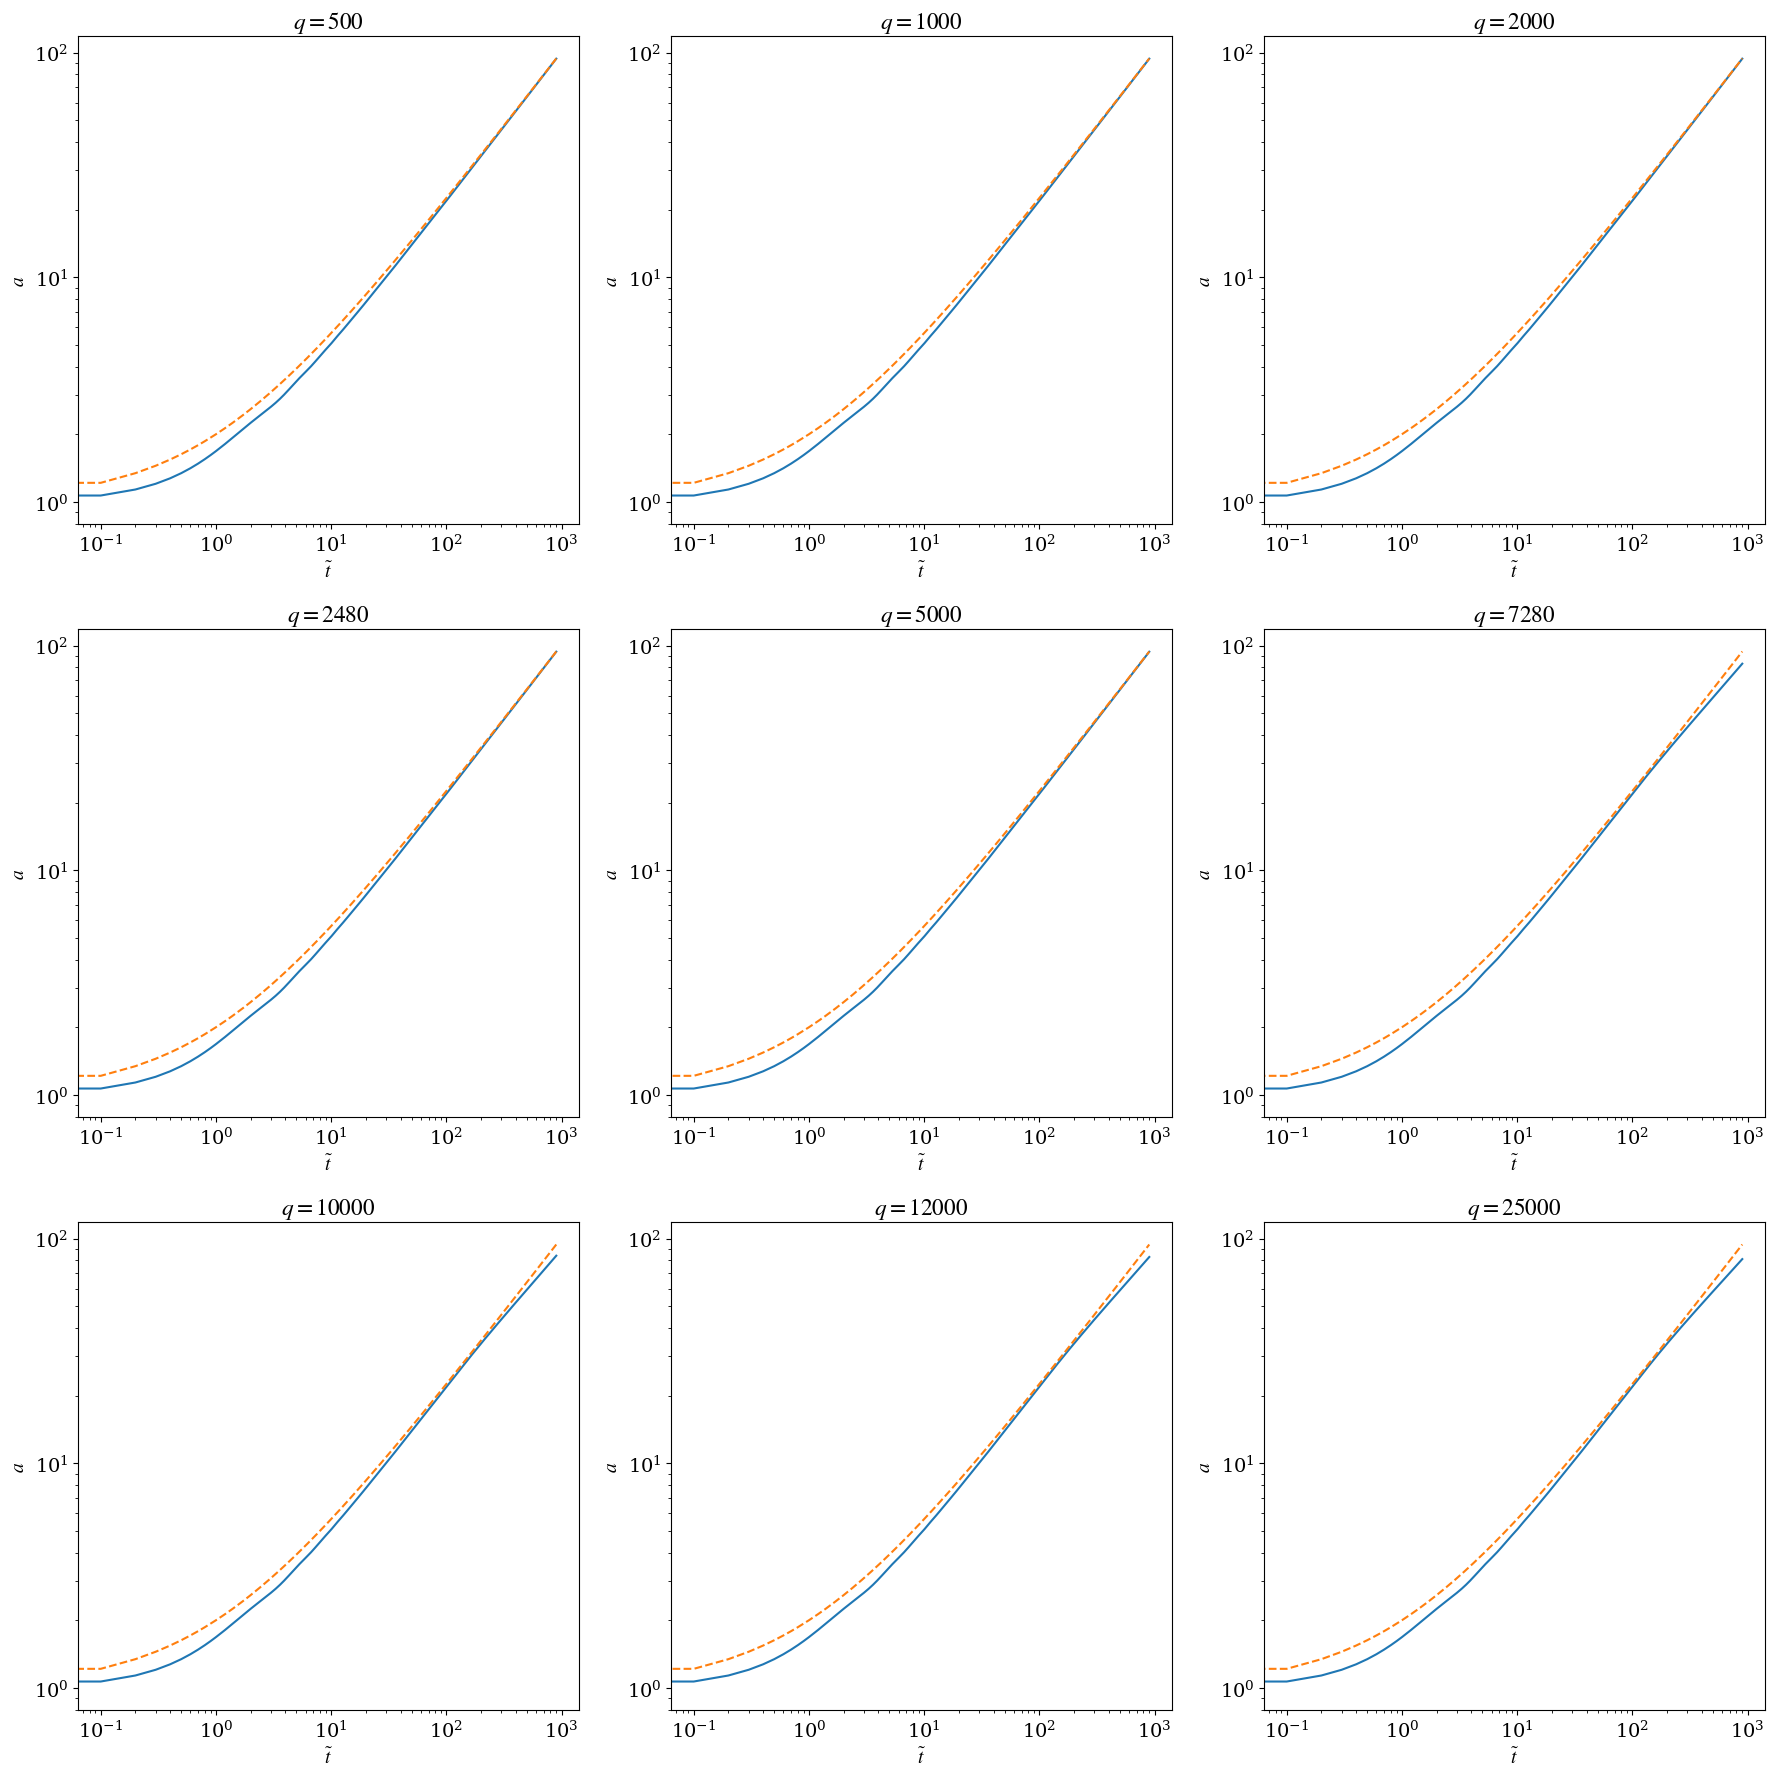

In [4]:
def plot_scale_factor_case(aDat_m2phi2, q_labels):
    plt.figure(figsize=(18, 18))

    # Tanh2 arriba
    for idx in range(9):
        plt.subplot(3, 3, idx+1)
        plt.plot(aDat_m2phi2[idx][:, 0], aDat_m2phi2[idx][:, 1])
        plt.plot(aDat_m2phi2[idx][:, 0], aDat_m2phi2[idx][:, 0]**(2/3) + 1, "--")
        plt.ylabel("$a$")
        plt.xlabel(r'$\tilde t$')
        plt.title(q_labels[idx])
        plt.xscale("log")
        plt.yscale("log")

    plt.tight_layout()
    plt.show()

q_labels = [
    r"$q = 500$",
    r"$q = 1000$",
    r"$q = 2000$",
    r"$q = 2480$",
    r"$q = 5000$",
    r"$q = 7280$",
    r"$q = 10000$",
    r"$q = 12000$",
    r"$q = 25000$",
]

plot_scale_factor_case([aDat_m2phi2_q500, aDat_m2phi2_q1000, aDat_m2phi2_q2000, aDat_m2phi2_q2480, aDat_m2phi2_q5000, aDat_m2phi2_q7280, aDat_m2phi2_q10000, aDat_m2phi2_q12000, aDat_m2phi2_q25000], q_labels)

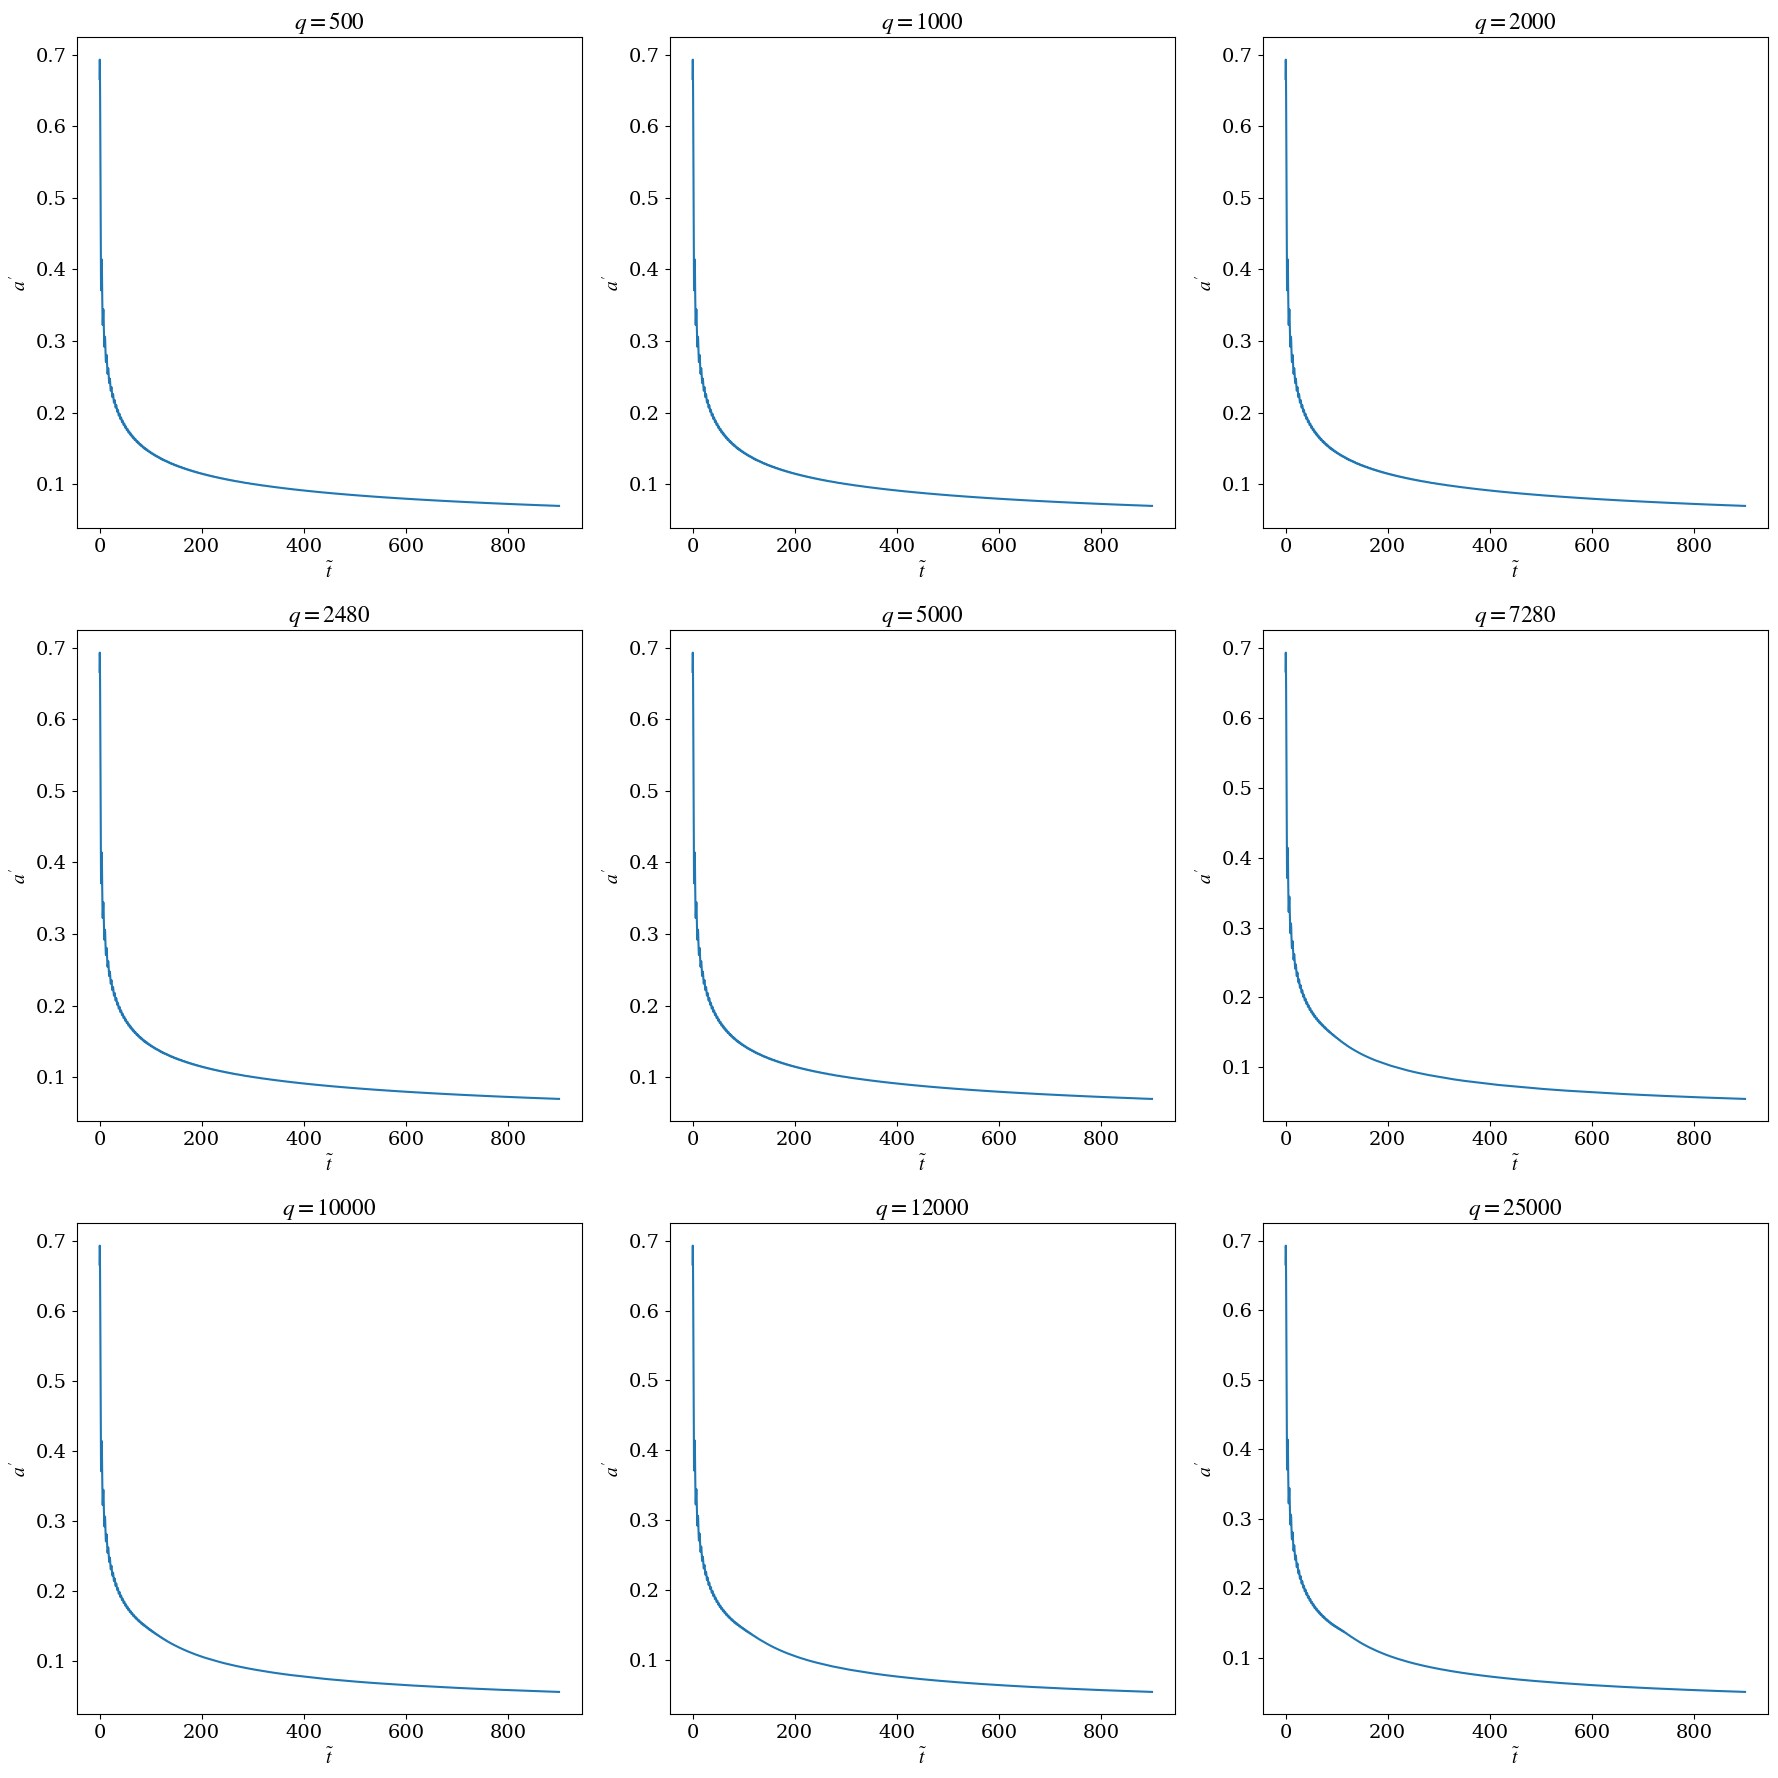

In [5]:
def plot_scale_factor_derivative_case(aDat_m2phi2, q_labels):
    plt.figure(figsize=(18, 18))

    # Tanh2 arriba
    for idx in range(9):
        plt.subplot(3, 3, idx+1)
        plt.plot(aDat_m2phi2[idx][:, 0], aDat_m2phi2[idx][:, 2])
        plt.ylabel("$a'$")
        plt.xlabel(r'$\tilde t$')
        plt.title(q_labels[idx])
    
    plt.tight_layout()
    plt.show()

q_labels = [
    r"$q = 500$",
    r"$q = 1000$",
    r"$q = 2000$",
    r"$q = 2480$",
    r"$q = 5000$",
    r"$q = 7280$",
    r"$q = 10000$",
    r"$q = 12000$",
    r"$q = 25000$",
]

plot_scale_factor_derivative_case([aDat_m2phi2_q500, aDat_m2phi2_q1000, aDat_m2phi2_q2000, aDat_m2phi2_q2480, aDat_m2phi2_q5000, aDat_m2phi2_q7280, aDat_m2phi2_q10000, aDat_m2phi2_q12000, aDat_m2phi2_q25000], q_labels)

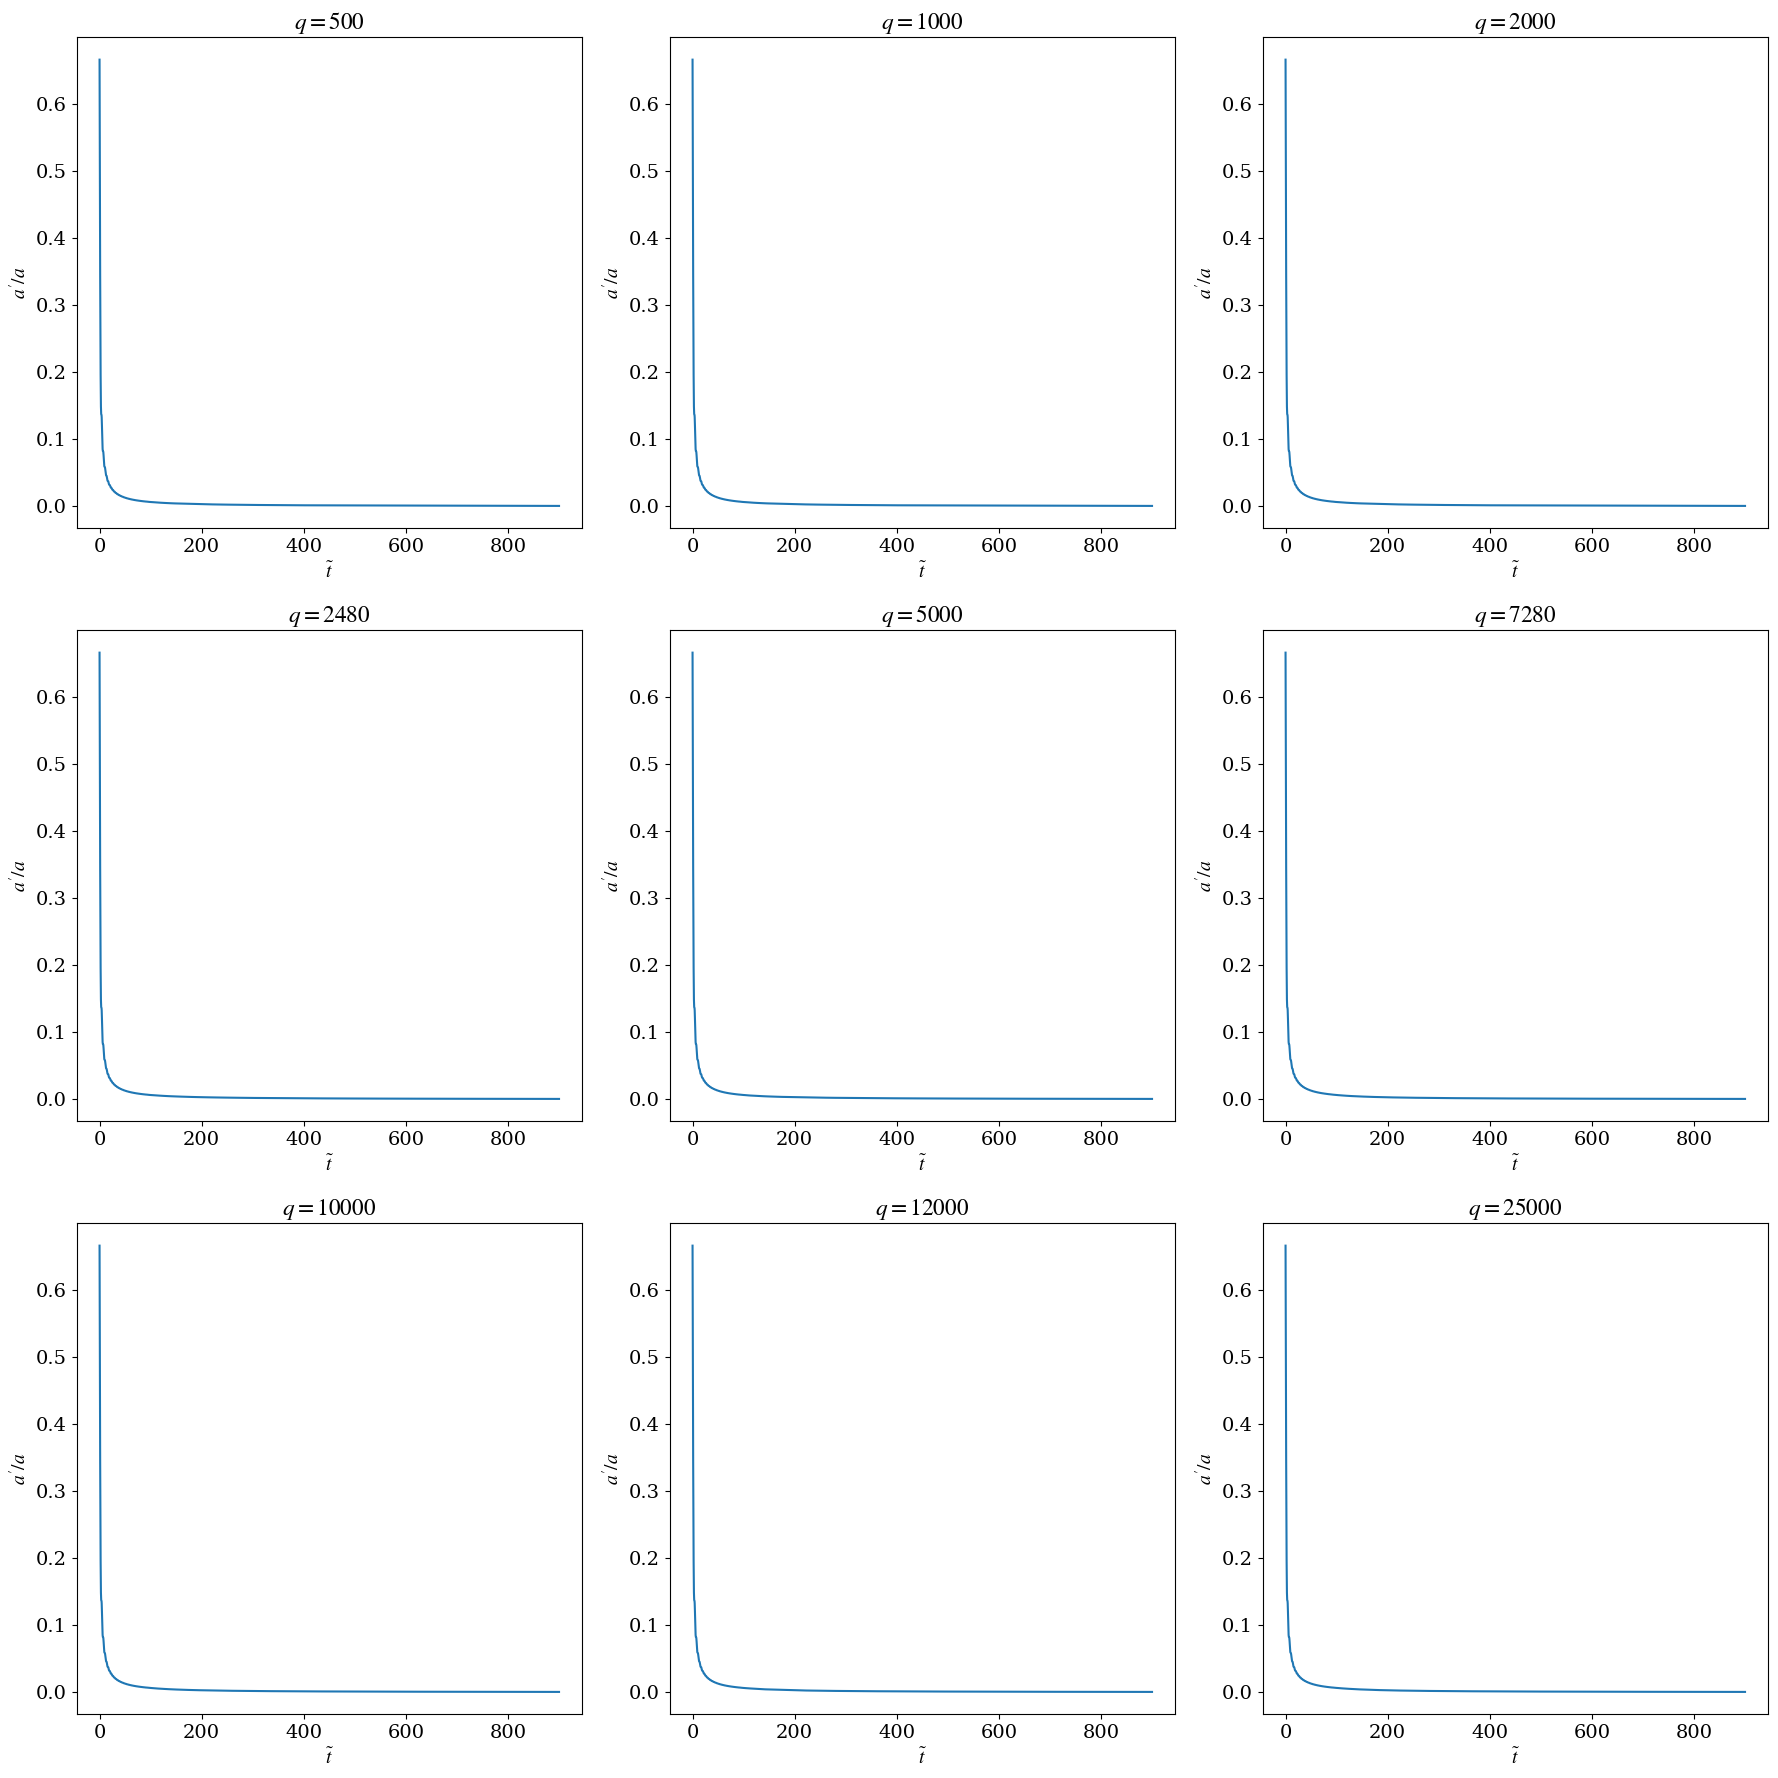

In [6]:
def plot_scale_factor_ratio_case(aDat_m2phi2, q_labels):
    plt.figure(figsize=(18, 18))

    # Tanh2 arriba
    for idx in range(9):
        plt.subplot(3, 3, idx+1)
        plt.plot(aDat_m2phi2[idx][:, 0], aDat_m2phi2[idx][:, 3])  # Cambia a [:, 3] para a'/a
        plt.ylabel("$a'/a$")
        plt.xlabel(r'$\tilde t$')
        plt.title(q_labels[idx])

    plt.tight_layout()
    plt.show()

q_labels = [
    r"$q = 500$",
    r"$q = 1000$",
    r"$q = 2000$",
    r"$q = 2480$",
    r"$q = 5000$",
    r"$q = 7280$",
    r"$q = 10000$",
    r"$q = 12000$",
    r"$q = 25000$",
]

plot_scale_factor_ratio_case([aDat_m2phi2_q500, aDat_m2phi2_q1000, aDat_m2phi2_q2000, aDat_m2phi2_q2480, aDat_m2phi2_q5000, aDat_m2phi2_q7280, aDat_m2phi2_q10000, aDat_m2phi2_q12000, aDat_m2phi2_q25000], q_labels)

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [7]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1])
    plt.xlabel("$\\tilde\eta$")
    plt.ylabel("$a\cdot\langle\phi_"+ fldNum +" \\rangle$")

## Field $0$ (inflaton)

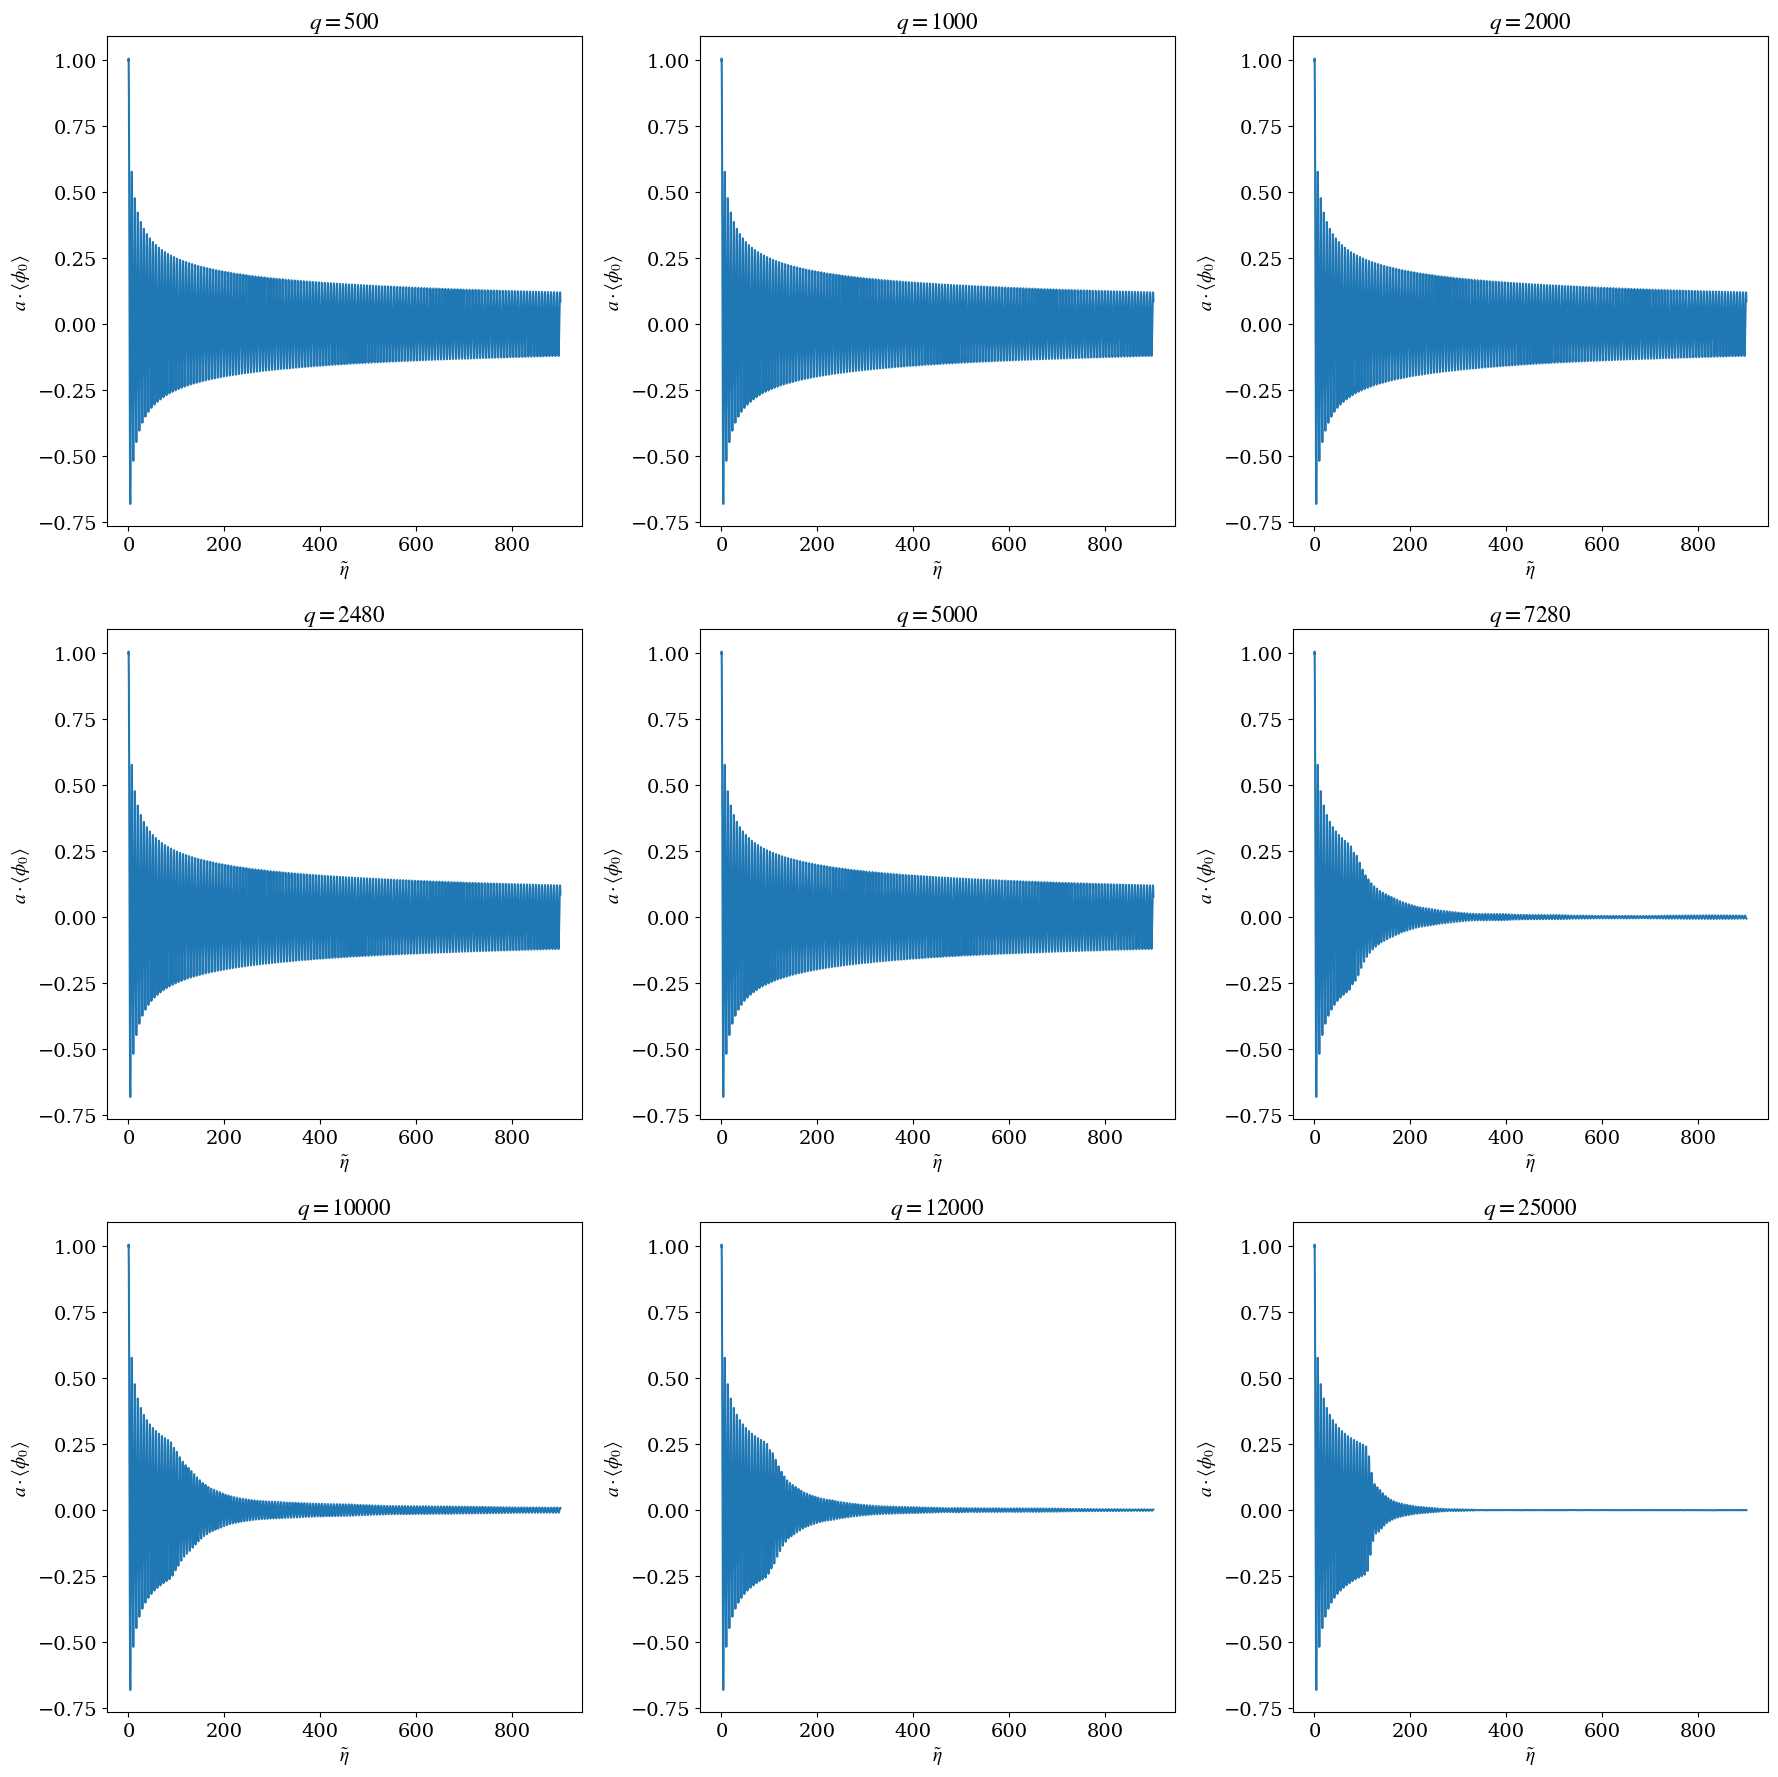

In [8]:
infDat_m2phi2_q500 = np.loadtxt(dir_m2phi2_q500 + "average_scalar_0.txt")
infDat_m2phi2_q1000 = np.loadtxt(dir_m2phi2_q1000 + "average_scalar_0.txt")
infDat_m2phi2_q2000 = np.loadtxt(dir_m2phi2_q2000 + "average_scalar_0.txt")
infDat_m2phi2_q2480 = np.loadtxt(dir_m2phi2_q2480 + "average_scalar_0.txt")
infDat_m2phi2_q5000 = np.loadtxt(dir_m2phi2_q5000 + "average_scalar_0.txt")
infDat_m2phi2_q7280 = np.loadtxt(dir_m2phi2_q7280 + "average_scalar_0.txt")
infDat_m2phi2_q10000 = np.loadtxt(dir_m2phi2_q10000 + "average_scalar_0.txt")
infDat_m2phi2_q12000 = np.loadtxt(dir_m2phi2_q12000 + "average_scalar_0.txt")
infDat_m2phi2_q25000 = np.loadtxt(dir_m2phi2_q25000 + "average_scalar_0.txt")

def plot_inflaton_case(infDat_m2phi2, aDat_m2phi2, q_labels):
    plt.figure(figsize=(18, 18))

    for idx in range(9):
        plt.subplot(3, 3, idx+1)
        plot_fld(infDat_m2phi2[idx], "0", aDat_m2phi2[idx])
        plt.title(q_labels[idx])

    plt.tight_layout()
    plt.show()

plot_inflaton_case([infDat_m2phi2_q500, infDat_m2phi2_q1000, infDat_m2phi2_q2000, infDat_m2phi2_q2480, infDat_m2phi2_q5000, infDat_m2phi2_q7280, infDat_m2phi2_q10000, infDat_m2phi2_q12000, infDat_m2phi2_q25000], [aDat_m2phi2_q500, aDat_m2phi2_q1000, aDat_m2phi2_q2000, aDat_m2phi2_q2480, aDat_m2phi2_q5000, aDat_m2phi2_q7280, aDat_m2phi2_q10000, aDat_m2phi2_q12000, aDat_m2phi2_q25000], q_labels)

## Field $1$ (daughter field)

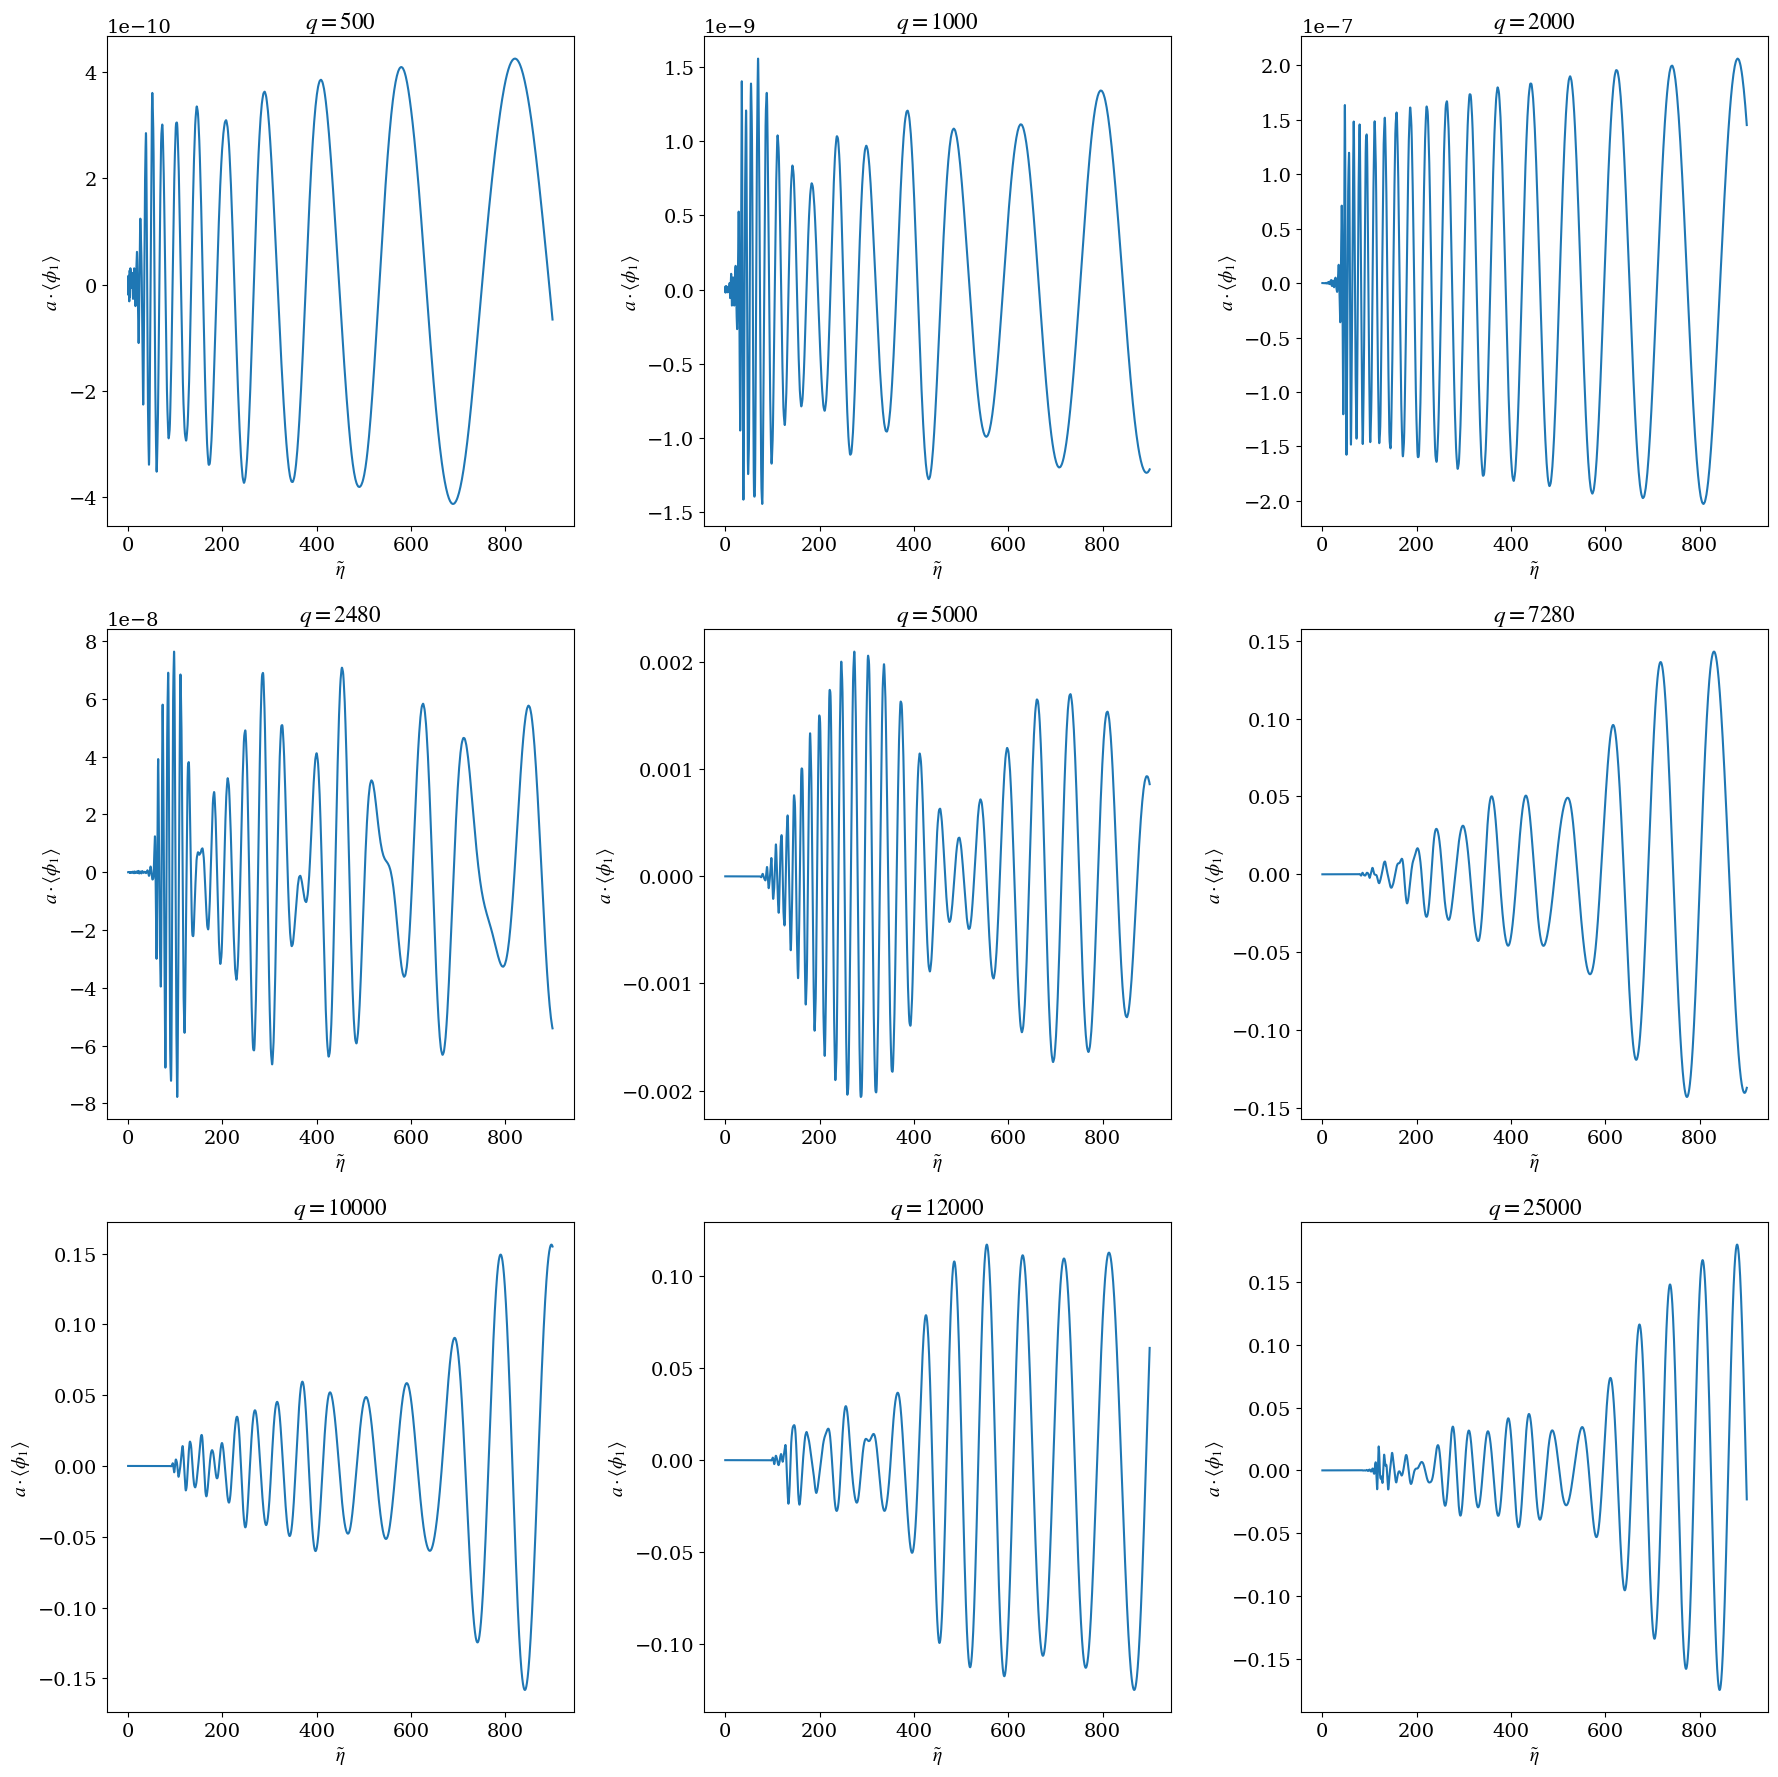

In [9]:
infDat_m2phi2_q500 = np.loadtxt(dir_m2phi2_q500 + "average_scalar_1.txt")
infDat_m2phi2_q1000 = np.loadtxt(dir_m2phi2_q1000 + "average_scalar_1.txt")
infDat_m2phi2_q2000 = np.loadtxt(dir_m2phi2_q2000 + "average_scalar_1.txt")
infDat_m2phi2_q2480 = np.loadtxt(dir_m2phi2_q2480 + "average_scalar_1.txt")
infDat_m2phi2_q5000 = np.loadtxt(dir_m2phi2_q5000 + "average_scalar_1.txt")
infDat_m2phi2_q7280 = np.loadtxt(dir_m2phi2_q7280 + "average_scalar_1.txt")
infDat_m2phi2_q10000 = np.loadtxt(dir_m2phi2_q10000 + "average_scalar_1.txt")
infDat_m2phi2_q12000 = np.loadtxt(dir_m2phi2_q12000 + "average_scalar_1.txt")
infDat_m2phi2_q25000 = np.loadtxt(dir_m2phi2_q25000 + "average_scalar_1.txt")

def plot_inflaton_case(infDat_m2phi2, aDat_m2phi2, q_labels):
    plt.figure(figsize=(18, 18))

    for idx in range(9):
        plt.subplot(3, 3, idx+1)
        plot_fld(infDat_m2phi2[idx], "1", aDat_m2phi2[idx])
        plt.title(q_labels[idx])

    plt.tight_layout()
    plt.show()

plot_inflaton_case([infDat_m2phi2_q500, infDat_m2phi2_q1000, infDat_m2phi2_q2000, infDat_m2phi2_q2480, infDat_m2phi2_q5000, infDat_m2phi2_q7280, infDat_m2phi2_q10000, infDat_m2phi2_q12000, infDat_m2phi2_q25000], [aDat_m2phi2_q500, aDat_m2phi2_q1000, aDat_m2phi2_q2000, aDat_m2phi2_q2480, aDat_m2phi2_q5000, aDat_m2phi2_q7280, aDat_m2phi2_q10000, aDat_m2phi2_q12000, aDat_m2phi2_q25000], q_labels)

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

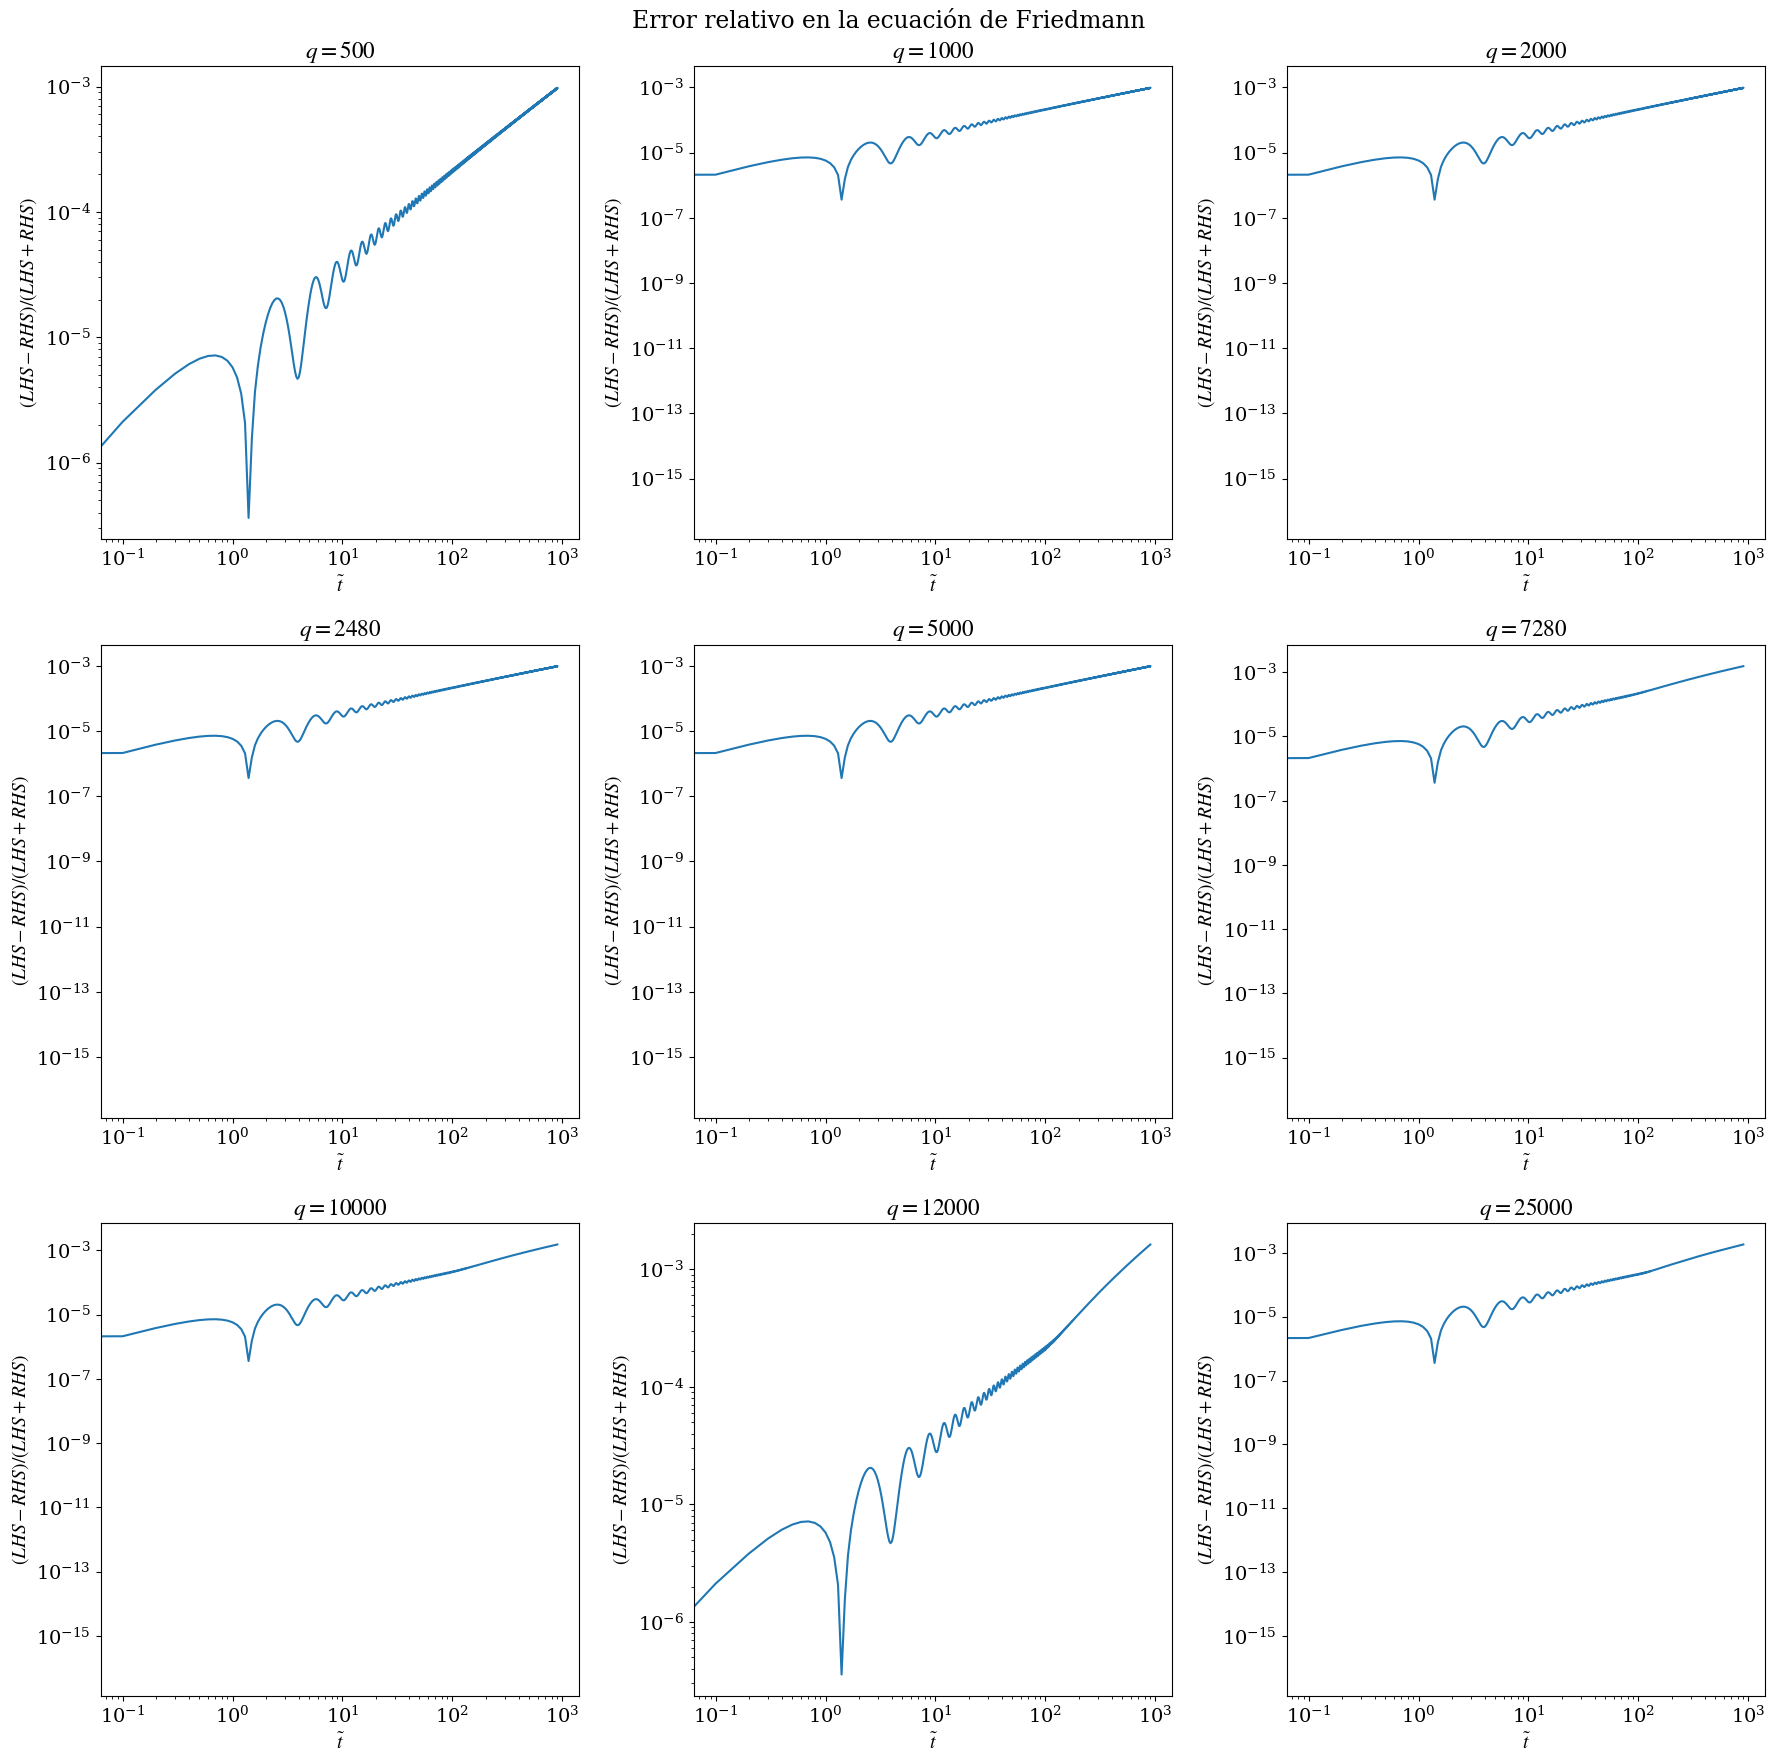

In [10]:
enConsDat_m2phi2_q500 = np.loadtxt(dir_m2phi2_q500 + "average_energy_conservation.txt")
enConsDat_m2phi2_q1000 = np.loadtxt(dir_m2phi2_q1000 + "average_energy_conservation.txt")
enConsDat_m2phi2_q2000 = np.loadtxt(dir_m2phi2_q2000 + "average_energy_conservation.txt")
enConsDat_m2phi2_q2480 = np.loadtxt(dir_m2phi2_q2480 + "average_energy_conservation.txt")
enConsDat_m2phi2_q5000 = np.loadtxt(dir_m2phi2_q5000 + "average_energy_conservation.txt")
enConsDat_m2phi2_q7280 = np.loadtxt(dir_m2phi2_q7280 + "average_energy_conservation.txt")
enConsDat_m2phi2_q10000 = np.loadtxt(dir_m2phi2_q10000 + "average_energy_conservation.txt")
enConsDat_m2phi2_q12000 = np.loadtxt(dir_m2phi2_q12000 + "average_energy_conservation.txt")
enConsDat_m2phi2_q25000 = np.loadtxt(dir_m2phi2_q25000 + "average_energy_conservation.txt")

def plot_energy_conservation_case(enConsDat_m2phi2, q_labels):
    plt.figure(figsize=(18, 18))

    for idx in range(9):
        plt.subplot(3, 3, idx+1)
        plt.plot(enConsDat_m2phi2[idx][:,0], np.abs(enConsDat_m2phi2[idx][:,1]))
        plt.title(q_labels[idx])
        plt.yscale('log')
        plt.xscale('log')
        plt.xlabel(r'$\tilde t$')
        plt.ylabel(r'$(LHS - RHS)/(LHS + RHS)$')

    plt.suptitle(r"Error relativo en la ecuación de Friedmann")
    plt.tight_layout()
    plt.show()

plot_energy_conservation_case([enConsDat_m2phi2_q500, enConsDat_m2phi2_q1000, enConsDat_m2phi2_q2000, enConsDat_m2phi2_q2480, enConsDat_m2phi2_q5000, enConsDat_m2phi2_q7280, enConsDat_m2phi2_q10000, enConsDat_m2phi2_q12000, enConsDat_m2phi2_q25000], q_labels)

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

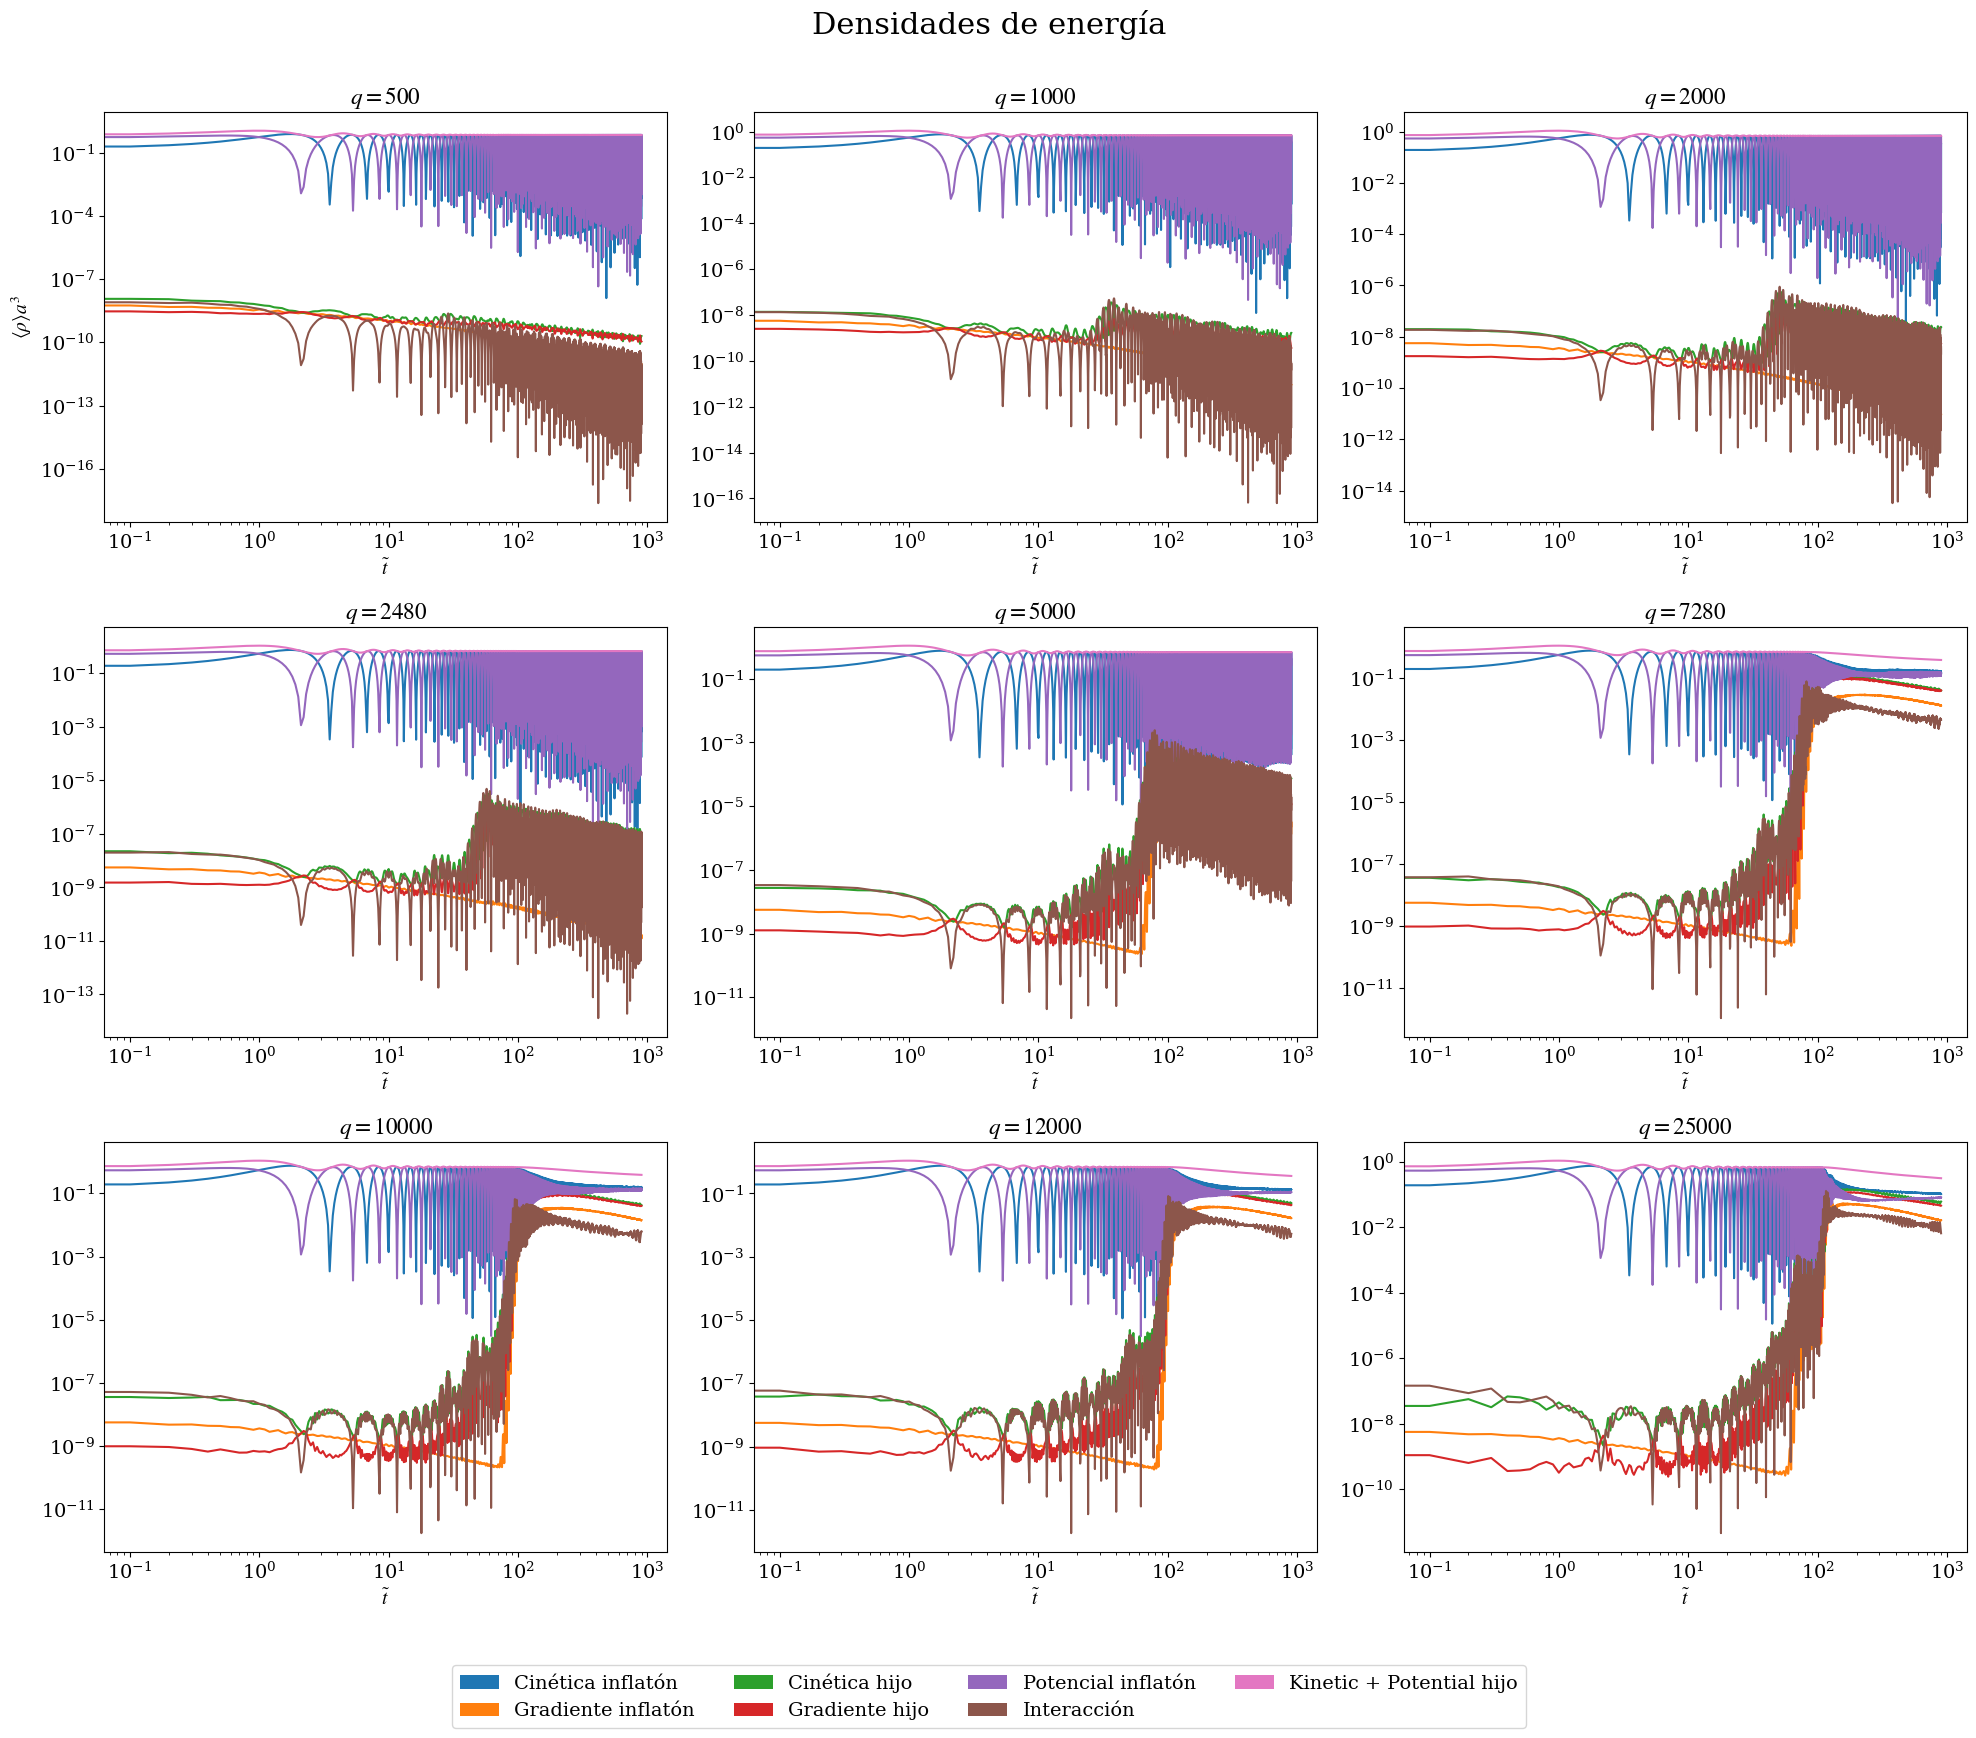

In [11]:
from matplotlib.patches import Patch

enDat_m2phi2_q500 = np.loadtxt(dir_m2phi2_q500 + "average_energies.txt")
enDat_m2phi2_q1000 = np.loadtxt(dir_m2phi2_q1000 + "average_energies.txt")
enDat_m2phi2_q2000 = np.loadtxt(dir_m2phi2_q2000 + "average_energies.txt")
enDat_m2phi2_q2480 = np.loadtxt(dir_m2phi2_q2480 + "average_energies.txt")
enDat_m2phi2_q5000 = np.loadtxt(dir_m2phi2_q5000 + "average_energies.txt")
enDat_m2phi2_q7280 = np.loadtxt(dir_m2phi2_q7280 + "average_energies.txt")
enDat_m2phi2_q10000 = np.loadtxt(dir_m2phi2_q10000 + "average_energies.txt")
enDat_m2phi2_q12000 = np.loadtxt(dir_m2phi2_q12000 + "average_energies.txt")
enDat_m2phi2_q25000 = np.loadtxt(dir_m2phi2_q25000 + "average_energies.txt")

def plot_combined_models_case(enDat, aDat, q_val_labels):
    
    # Etiquetas de las componentes y colores
    labels = ["Cinética inflatón", "Gradiente inflatón", "Cinética hijo", "Gradiente hijo", 
              "Potencial inflatón", "Interacción", "Kinetic + Potential hijo"]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]
    
    fig = plt.figure(figsize=(20, 18))
    
    for idx in range(9):
        row, col = divmod(idx, 3)
        ax = plt.subplot2grid((3, 3), (row, col))
        enDat_i = enDat[idx]
        aDat_i = aDat[idx]
        for comp in range(1, enDat_i.shape[1]):
            ax.plot(enDat_i[:,0], enDat_i[:,comp] * aDat_i[:,1]**3, color=colors[comp-1])
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_title(fr"{q_val_labels[idx]}")
        ax.set_xlabel(r"$\tilde{t}$")
        if idx == 0: ax.set_ylabel(r"$\langle \rho \rangle a^3$")

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    # Leyenda general
    legend_elements = [Patch(facecolor=colors[i], label=labels[i]) for i in range(len(labels))]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=4, fontsize=14)

    plt.suptitle(fr"Densidades de energía", fontsize=22)
    plt.show()

# Llamada para el caso m1
plot_combined_models_case([enDat_m2phi2_q500, enDat_m2phi2_q1000, enDat_m2phi2_q2000, enDat_m2phi2_q2480, enDat_m2phi2_q5000, enDat_m2phi2_q7280, enDat_m2phi2_q10000, enDat_m2phi2_q12000, enDat_m2phi2_q25000], [aDat_m2phi2_q500, aDat_m2phi2_q1000, aDat_m2phi2_q2000, aDat_m2phi2_q2480, aDat_m2phi2_q5000, aDat_m2phi2_q7280, aDat_m2phi2_q10000, aDat_m2phi2_q12000, aDat_m2phi2_q25000], q_labels)

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [12]:
def load_spectrum(filename, comment='#'):
    """Función para cargar los espectros manejando los saltos de línea de CosmoLattice."""
    with open(filename, 'r') as file:
        nBins = 0
        line = file.readline()
        while line and line != "\n":
            if line[0] != comment:
                nBins += 1
            line = file.readline()
    
    fileSp = np.loadtxt(filename, comments=comment)
    nSpectra = len(fileSp) // nBins
    return fileSp, int(nBins), int(nSpectra)

def plot_spectrum_into_ax(ax, spectra, column, nBins, nSpectra, ylabel, colormap='plasma'):
    """Dibuja el espectro en un eje específico con una barra de color."""
    colors = plt.get_cmap(colormap)
    # Ajustamos el normalizador para que coincida con el tiempo de la simulación si es necesario
    norm = plt.Normalize(vmin=0, vmax=nSpectra-1)
    
    for i in range(nSpectra):
        ax.plot(
            spectra[i*nBins:(i+1)*nBins, 0],
            spectra[i*nBins:(i+1)*nBins, column],
            color=colors(i / nSpectra),
            alpha=0.8
        )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\tilde{k}$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    
    # Barra de color individual para cada subplot
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$t$', fontsize=12)

def plot_combined_spectra(field_num, dirs, q_val_labels, column=1):
    """
    field_num: 0 para inflatón, 1 para campo hijo.
    column: 1 para Espectro (Delta), 2 para Número de ocupación (nk).
    """
    field_name = "inflatón" if field_num == 0 else "hijo"
    quantity = "Espectro" if column == 1 else "Número de ocupación"
    ylabel = (r'$\tilde{\Delta}_{\tilde{\phi}}$' if field_num == 0 else r'$\tilde{\Delta}_{\tilde{\chi}}$') if column == 1 else (r'$\tilde{n}_{\tilde{\phi}}$' if field_num == 0 else r'$\tilde{n}_{\tilde{\chi}}$')
    
    filename = f"spectra_scalar_{field_num}.txt"
    fig = plt.figure(figsize=(20, 18))
    
    for idx in range(9):
        row, col = divmod(idx, 3)
        ax = plt.subplot2grid((3, 3), (row, col))
        path = os.path.join(dirs[idx], filename)
        if os.path.exists(path):
            sp, nBins, nSpec = load_spectrum(path)
            plot_spectrum_into_ax(ax, sp, column, nBins, nSpec, ylabel)
        ax.set_title(fr"{q_val_labels[idx]}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(fr"{quantity} del campo {field_name}", fontsize=22)
    plt.show()

## Inflaton

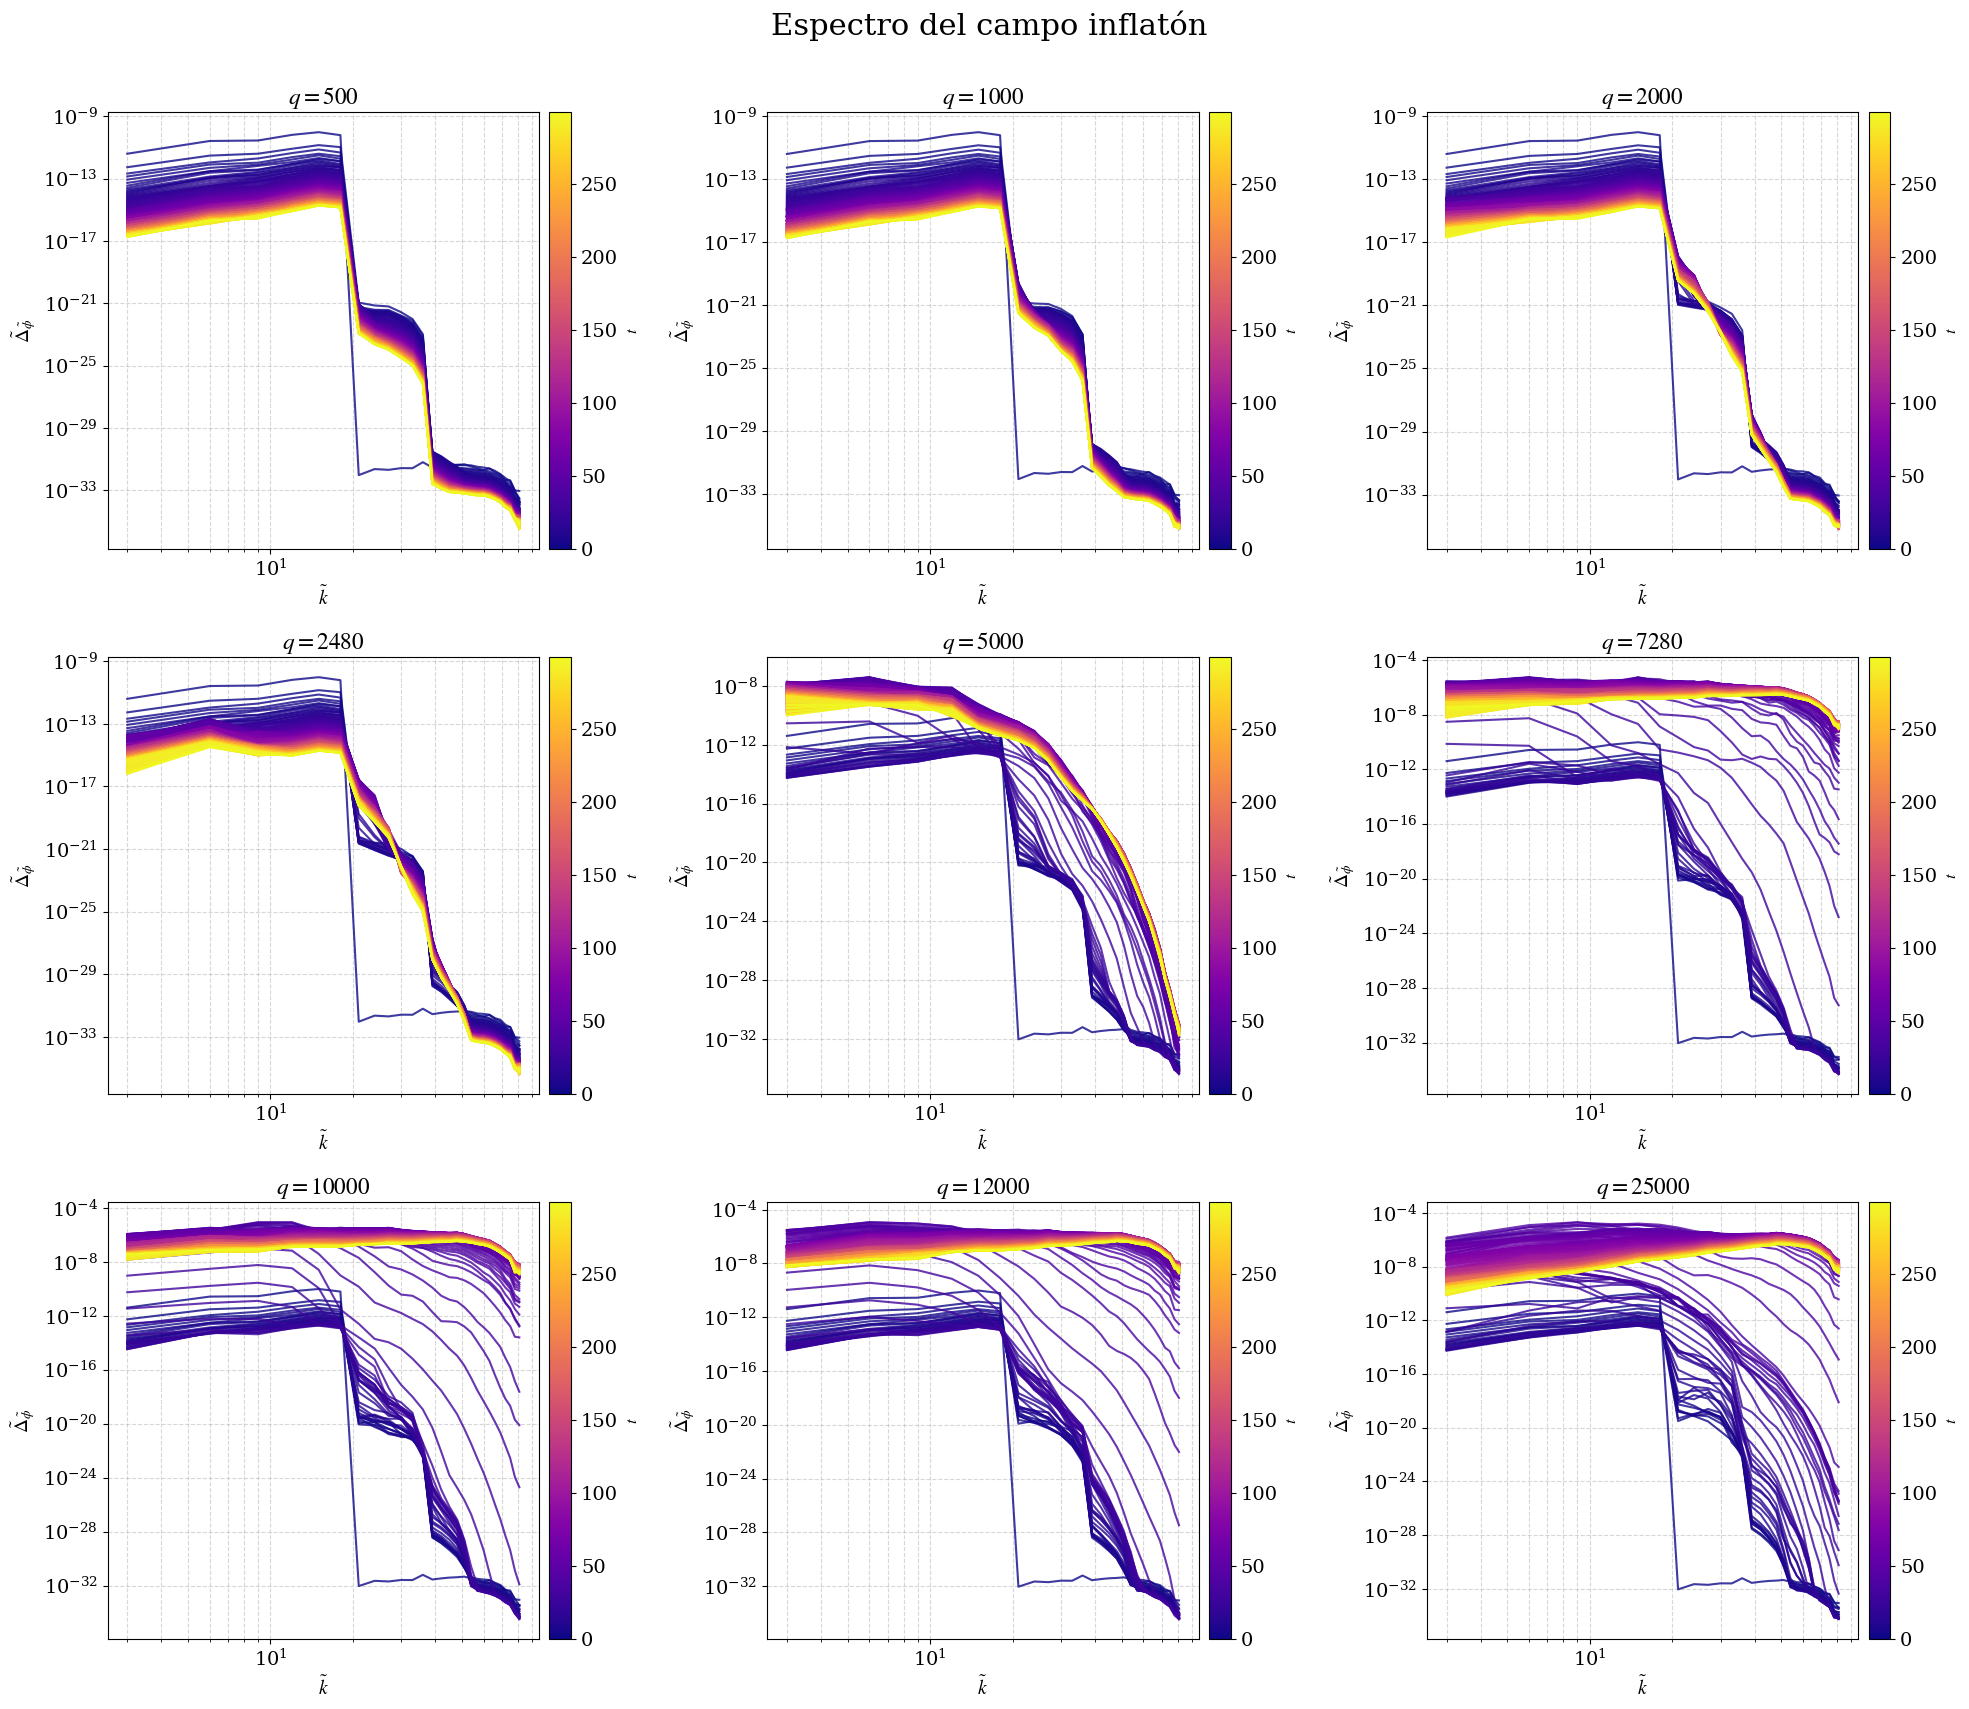

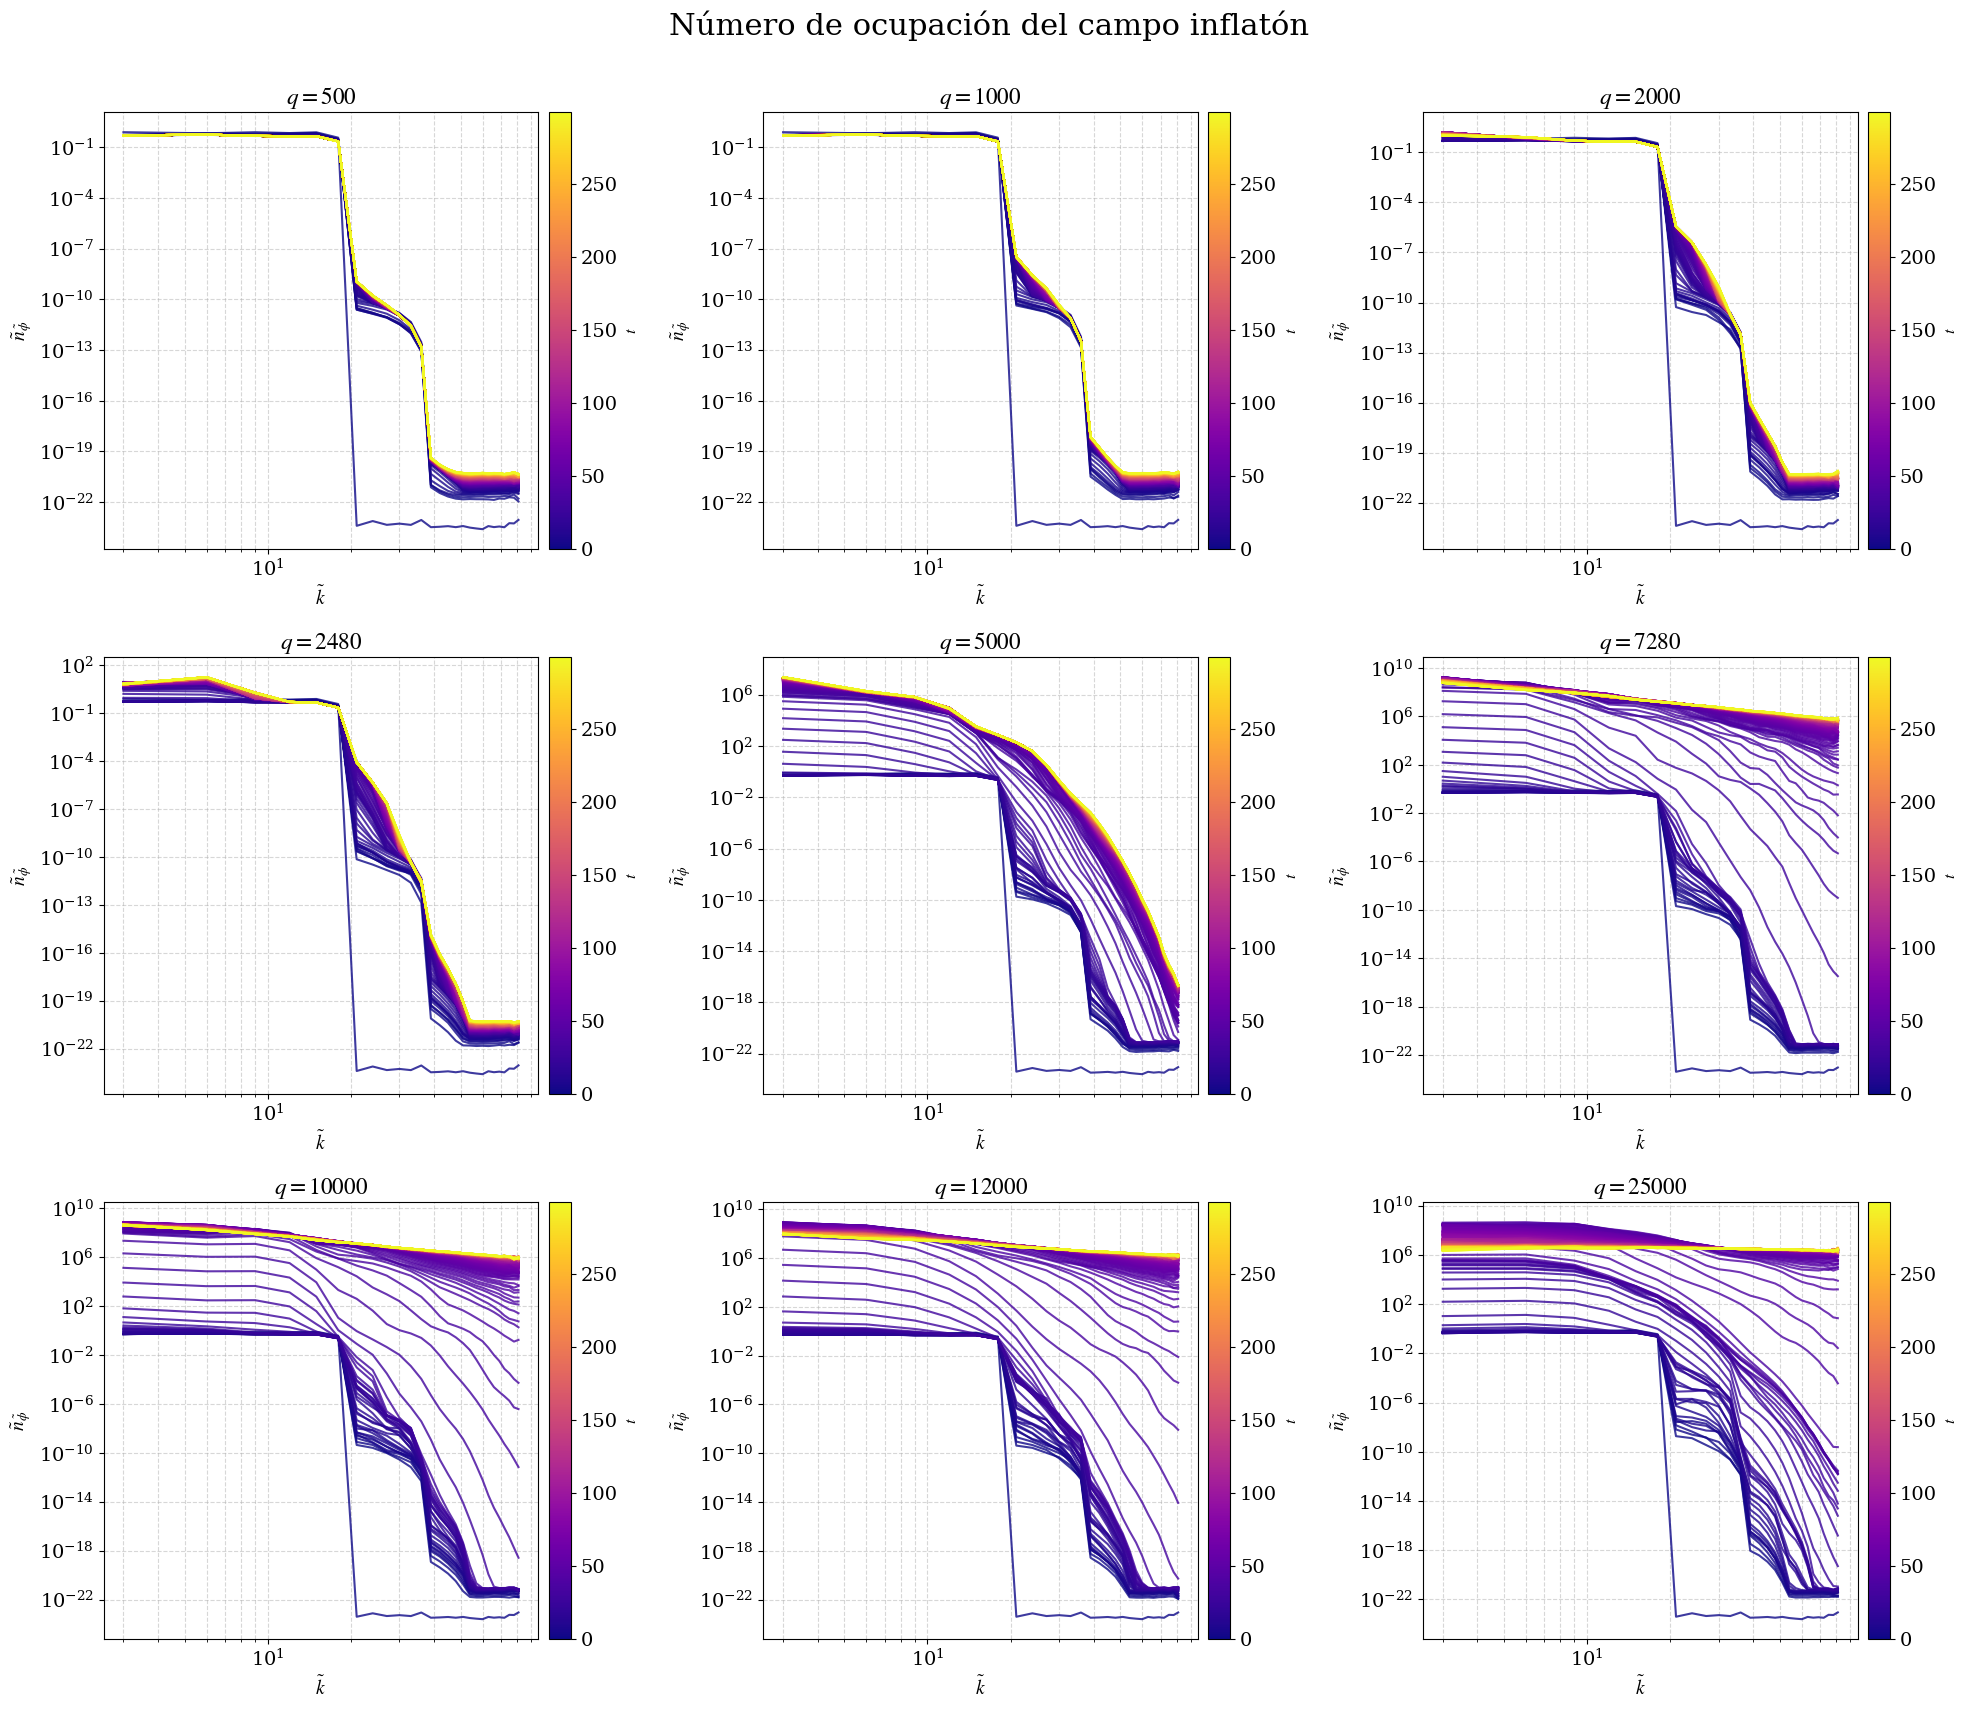

In [13]:
plot_combined_spectra(0,[dir_m2phi2_q500, dir_m2phi2_q1000, dir_m2phi2_q2000, dir_m2phi2_q2480, dir_m2phi2_q5000, dir_m2phi2_q7280, dir_m2phi2_q10000, dir_m2phi2_q12000, dir_m2phi2_q25000], q_labels, column=1)

plot_combined_spectra(0,[dir_m2phi2_q500, dir_m2phi2_q1000, dir_m2phi2_q2000, dir_m2phi2_q2480, dir_m2phi2_q5000, dir_m2phi2_q7280, dir_m2phi2_q10000, dir_m2phi2_q12000, dir_m2phi2_q25000], q_labels, column=3)

## Daughter field

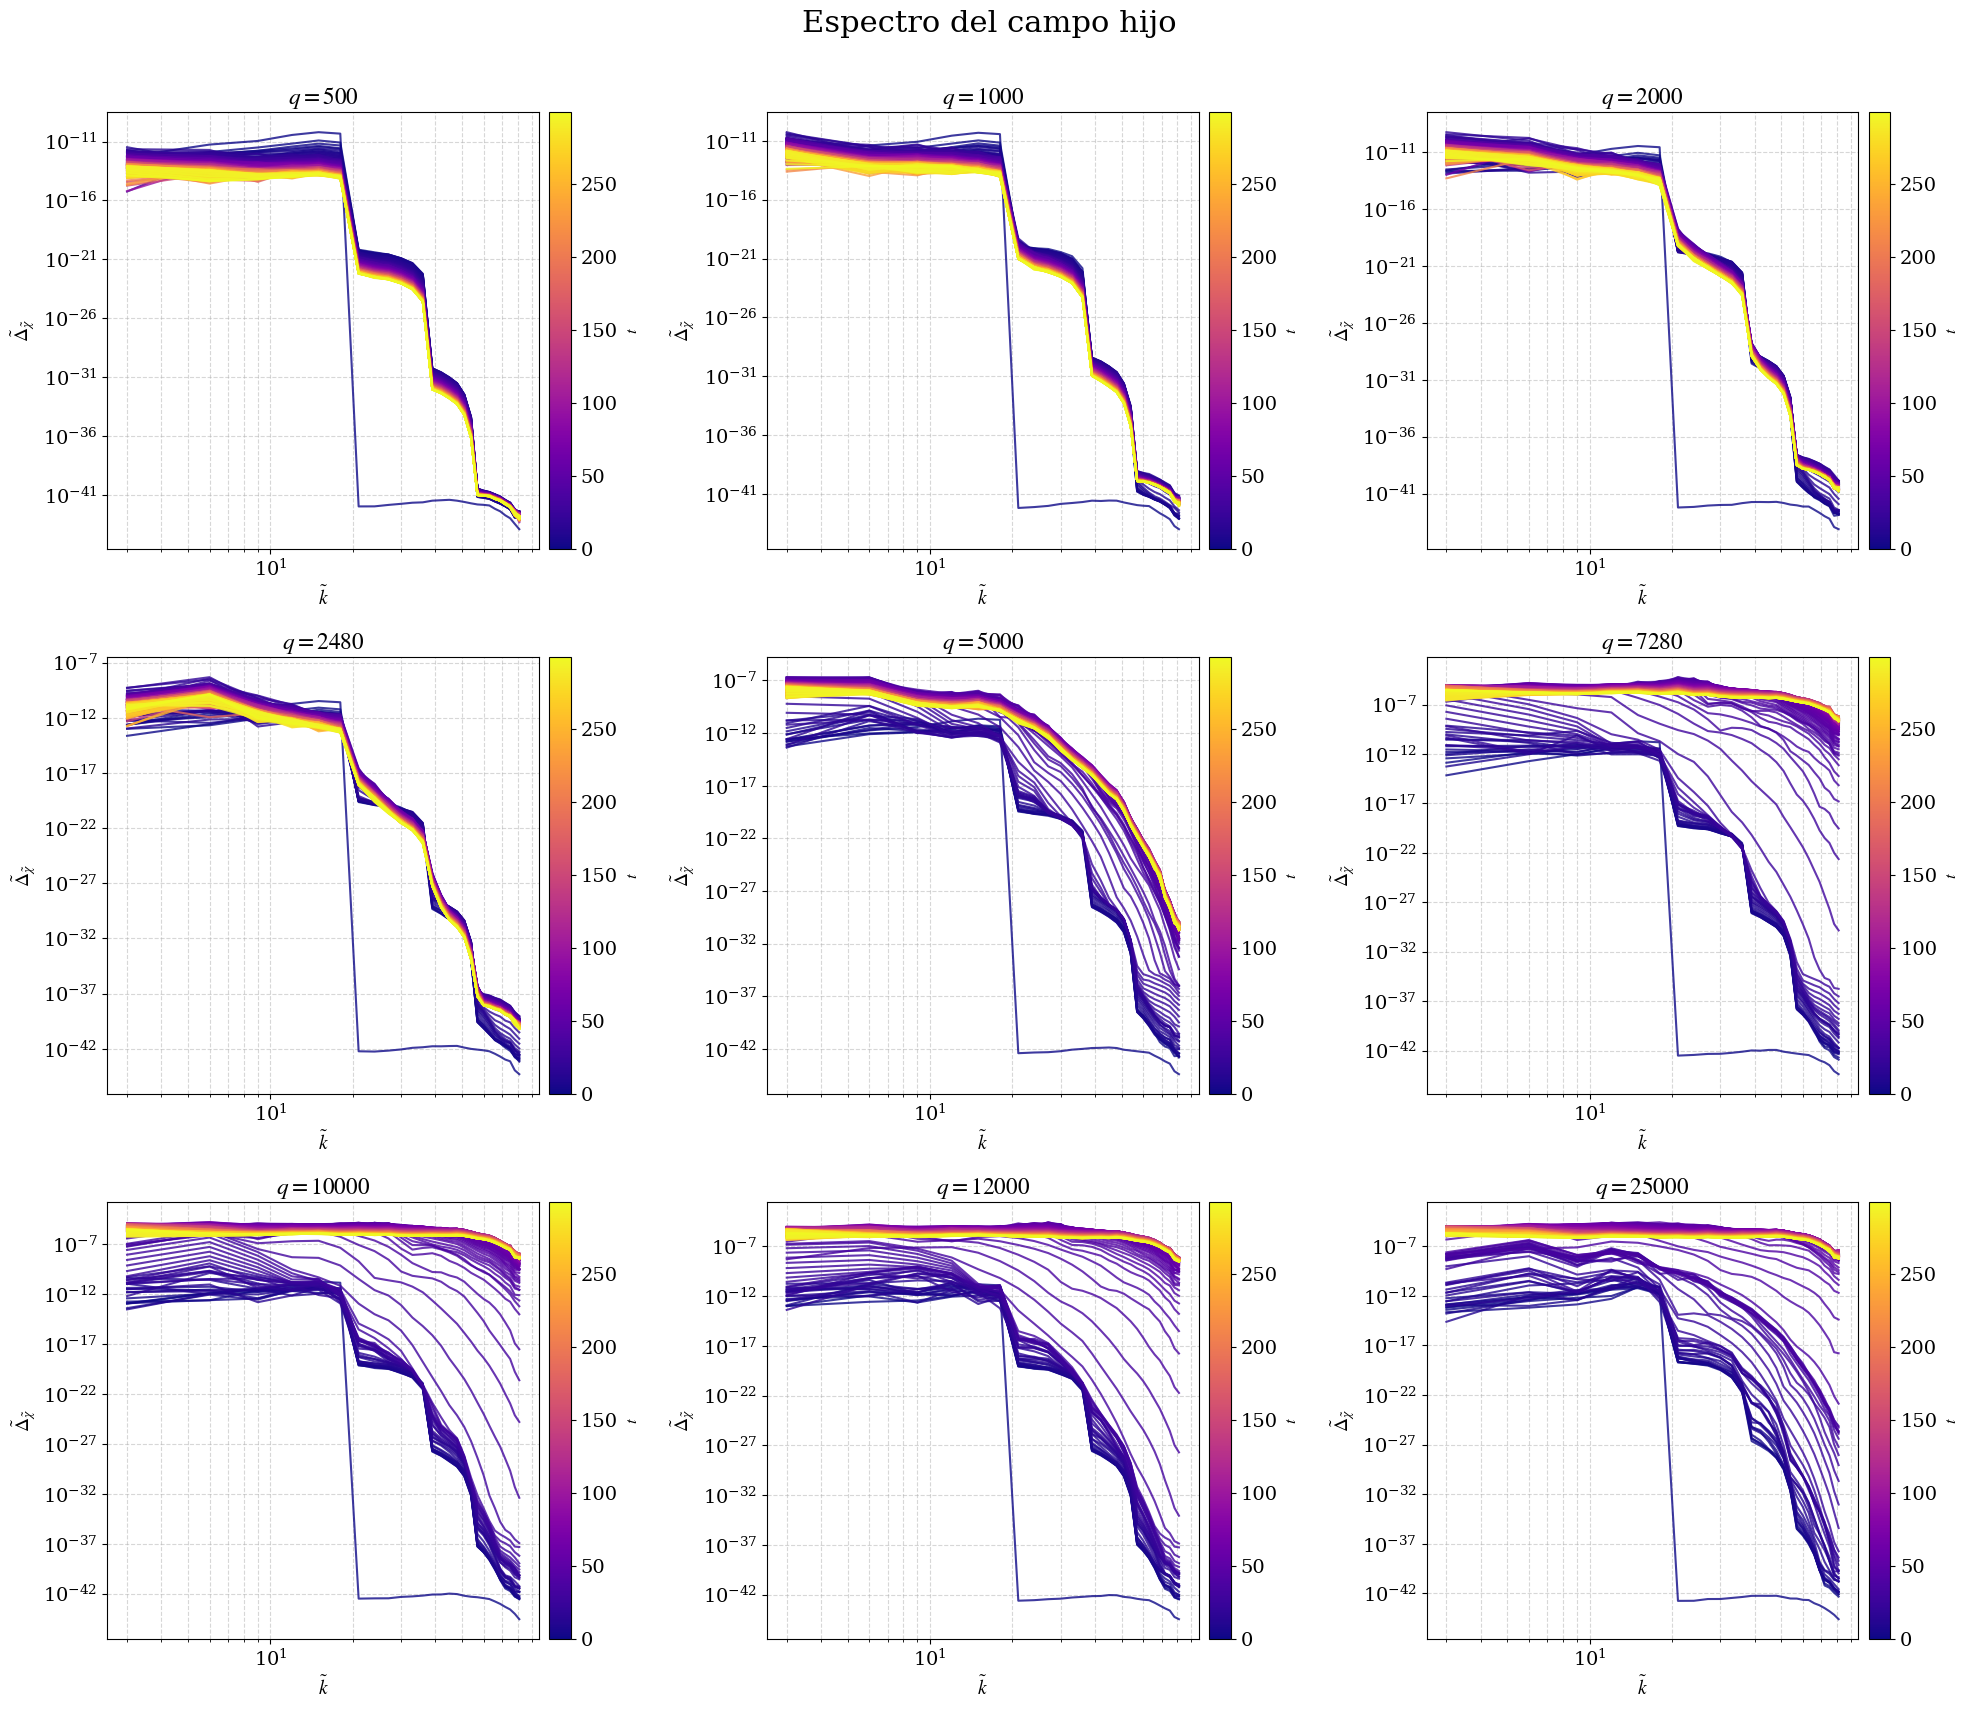

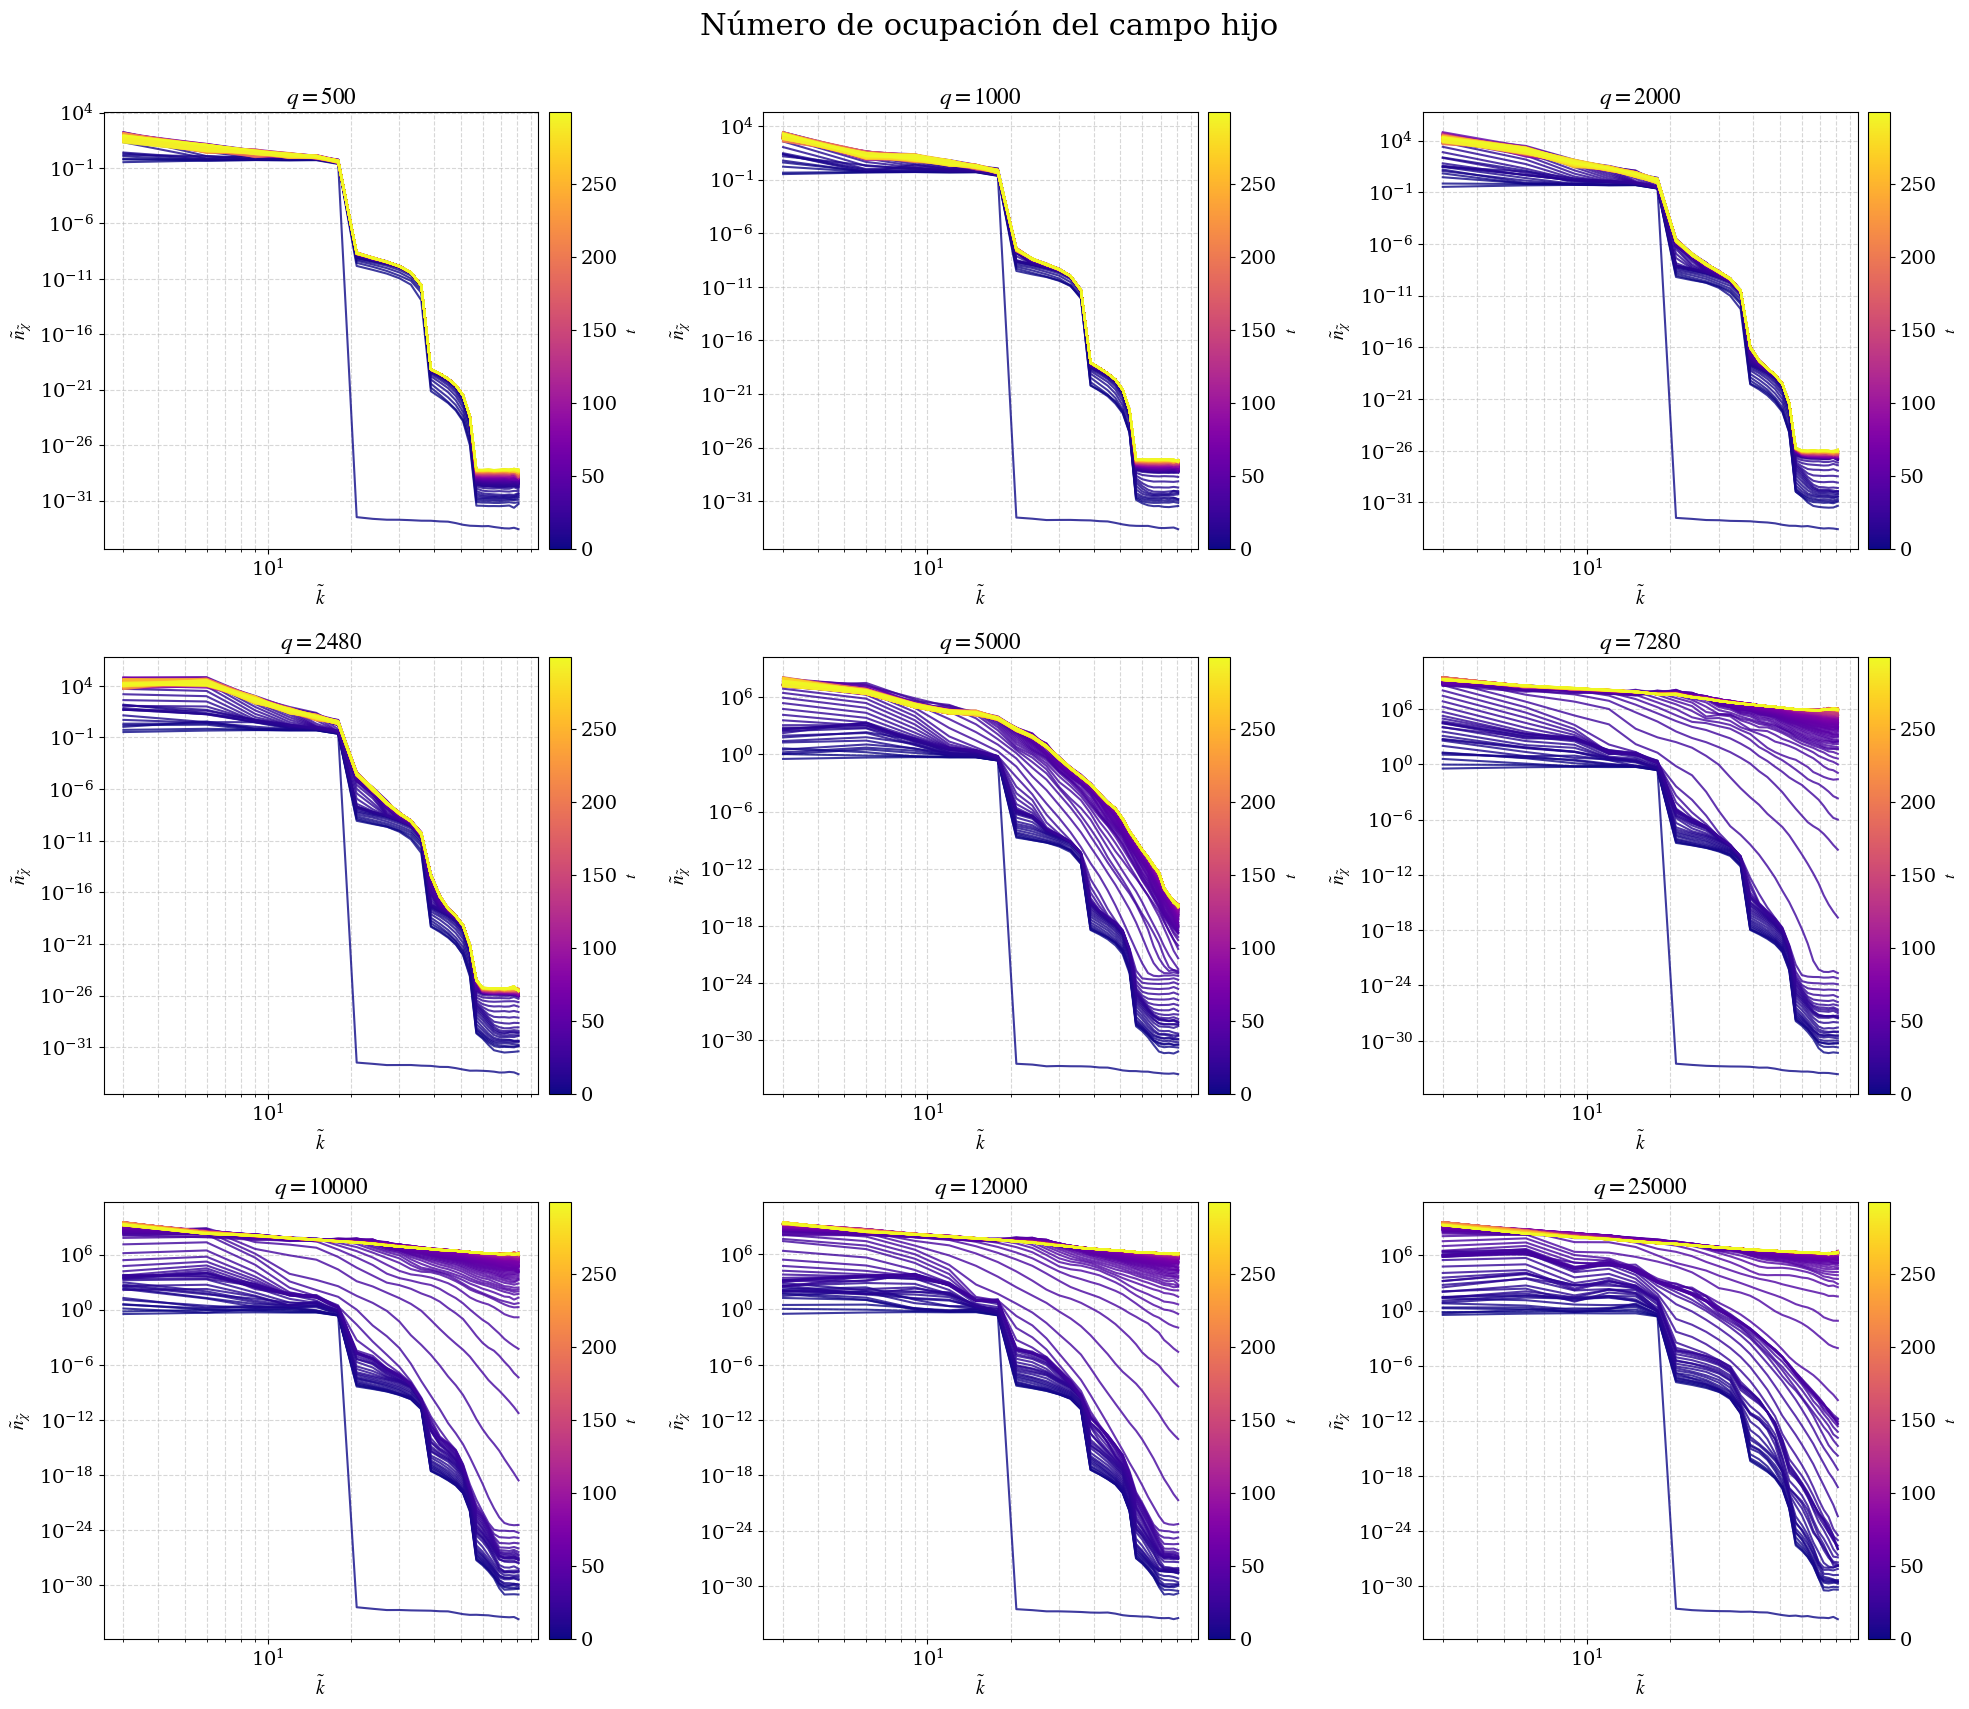

In [14]:
plot_combined_spectra(1,[dir_m2phi2_q500, dir_m2phi2_q1000, dir_m2phi2_q2000, dir_m2phi2_q2480, dir_m2phi2_q5000, dir_m2phi2_q7280, dir_m2phi2_q10000, dir_m2phi2_q12000, dir_m2phi2_q25000], q_labels, column=1)

plot_combined_spectra(1,[dir_m2phi2_q500, dir_m2phi2_q1000, dir_m2phi2_q2000, dir_m2phi2_q2480, dir_m2phi2_q5000, dir_m2phi2_q7280, dir_m2phi2_q10000, dir_m2phi2_q12000, dir_m2phi2_q25000], q_labels, column=3)

# GWs

In [15]:
def load_gws(filename, comment='#'):
    """Carga los espectros de GWs manejando los saltos de línea."""
    with open(filename, 'r') as file:
        nBins = 0
        line = file.readline()
        while line and line != "\n":
            if line[0] != comment:
                nBins += 1
            line = file.readline()
    
    fileSp = np.loadtxt(filename, comments=comment)
    nSpectra = len(fileSp) // nBins
    return fileSp, int(nBins), int(nSpectra)

def plot_gw_into_ax(ax, gw_data, nBins, nSpectra, ylabel=r'$\tilde{\Delta}_h$', colormap='viridis'):
    """Dibuja el espectro de GWs en un eje específico."""
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=nSpectra-1)
    
    for i in range(nSpectra):
        ax.plot(
            gw_data[i*nBins:(i+1)*nBins, 0],
            gw_data[i*nBins:(i+1)*nBins, 1], # La columna 1 suele ser el espectro de potencia
            color=colors(i / nSpectra),
            alpha=0.8
        )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\tilde{k}$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$t$', fontsize=12)

def plot_combined_gws_case(dirs, q_val_labels):
    
    filename = "spectra_gws.txt"
    fig = plt.figure(figsize=(20, 18))
    ylabel = r'$\tilde{\Delta}_h$'
    
    for i in range(9):
        row, col = divmod(i, 3)
        ax = plt.subplot2grid((3, 3), (row, col))
        path = os.path.join(dirs[i], filename)
        if os.path.exists(path):
            sp, nBins, nSpec = load_gws(path)
            plot_gw_into_ax(ax, sp, nBins, nSpec, ylabel, colormap='plasma')
        ax.set_title(fr"${q_val_labels[i]}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(fr"Espectro de Ondas Gravitacionales", fontsize=22)
    plt.show()

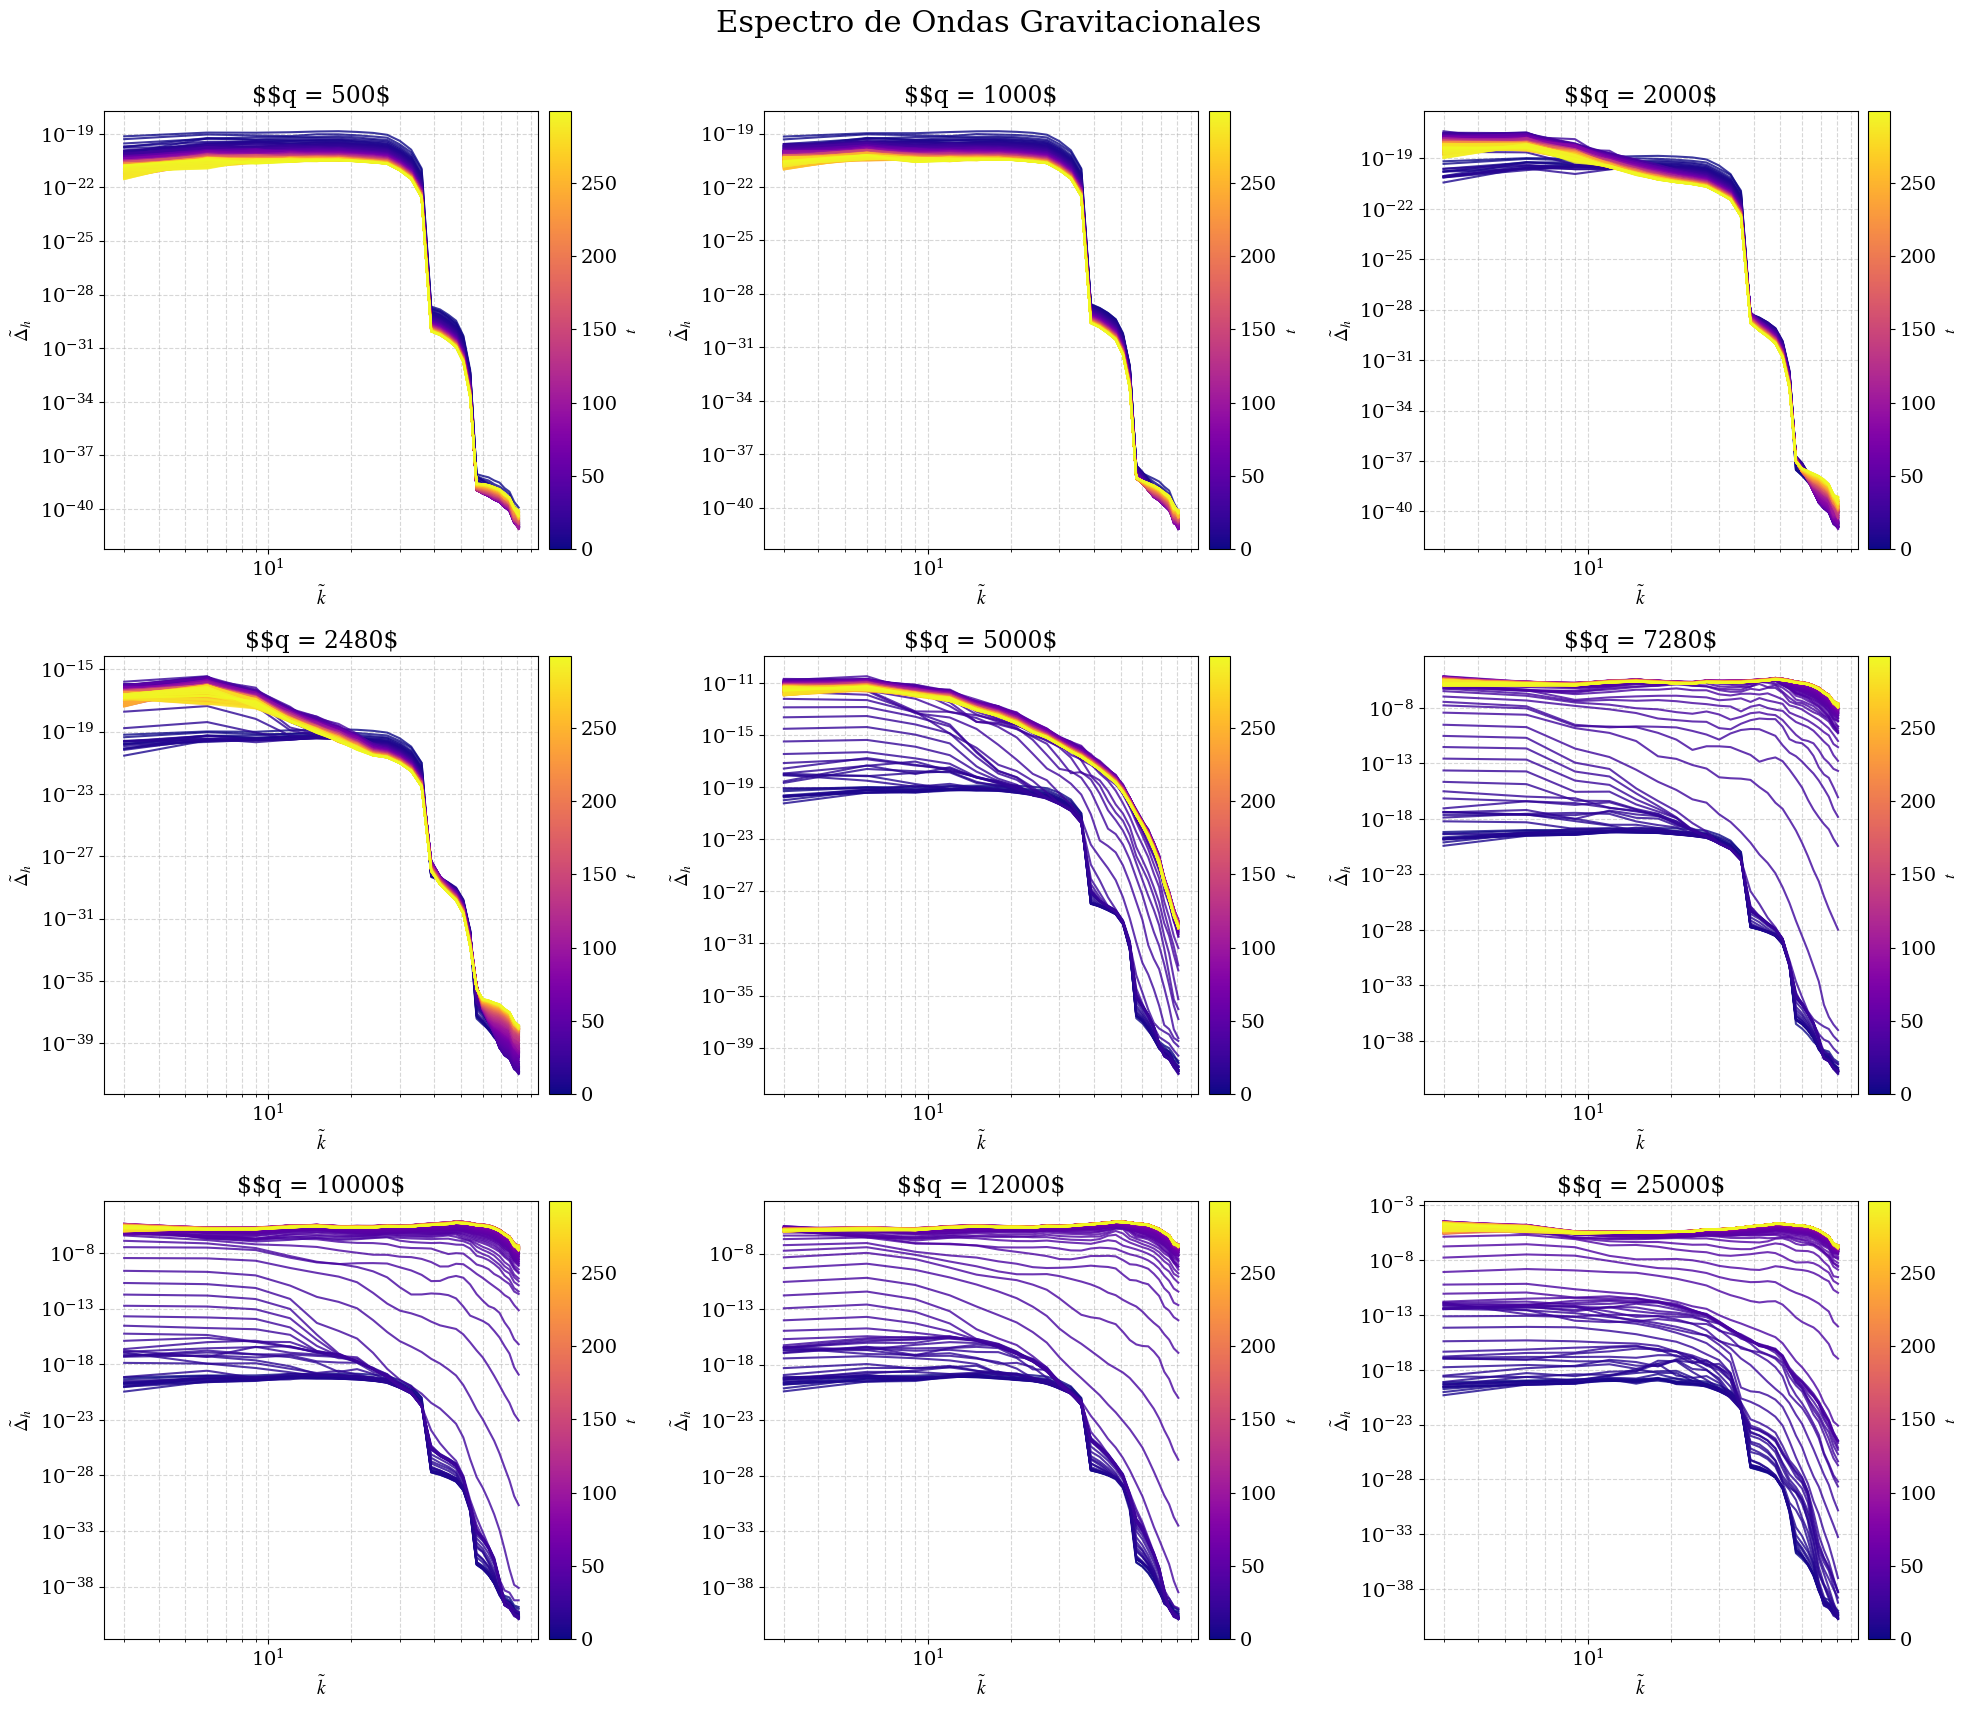

In [16]:
plot_combined_gws_case([dir_m2phi2_q500, dir_m2phi2_q1000, dir_m2phi2_q2000, dir_m2phi2_q2480, dir_m2phi2_q5000, dir_m2phi2_q7280, dir_m2phi2_q10000, dir_m2phi2_q12000, dir_m2phi2_q25000], q_labels)

In [17]:
def integrate_gw_spectrum(gw_data, nBins, nSpectra):
    """
    Integra el espectro de GWs para cada tiempo de salida.
    Utiliza la regla del trapecio sobre los datos del espectro.
    """
    total_energy = []
    for i in range(nSpectra):
        # Seleccionamos el bloque del espectro para el tiempo i
        # Columna 0: k_tilde, Columna 1: Delta_h
        k = gw_data[i*nBins:(i+1)*nBins, 0]
        delta_h = gw_data[i*nBins:(i+1)*nBins, 1]
        
        # Integración numérica
        energy = np.trapezoid(delta_h, k)
        total_energy.append(energy)
    return np.array(total_energy)

def plot_combined_gw_energies(dirs, q_val_labels):
    """
    Gráfica la evolución temporal de la energía total de las GWs.
    """
    filename = "spectra_gws.txt"
    fig = plt.figure(figsize=(20, 18))
    
    for i in range(9):
        row, col = divmod(i, 3)
        ax = plt.subplot2grid((3, 3), (row, col))
        path = os.path.join(dirs[i], filename)
        if os.path.exists(path):
            sp, nBins, nSpec = load_gws(path) # Usamos la función load_gws definida antes
            e_gw = integrate_gw_spectrum(sp, nBins, nSpec)
            # El eje x es el índice del espectro (o tiempo proporcional)
            ax.plot(np.arange(nSpec), e_gw, color='tab:red', lw=2)
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_title(fr"{q_val_labels[i]}")
        ax.set_xlabel(r"Índice de espectro ($t$)")
        if i == 0: ax.set_ylabel(r"$E_{GW}$ (Integrada)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(fr"Evolución de la Energía de GWs", fontsize=22)
    plt.show()

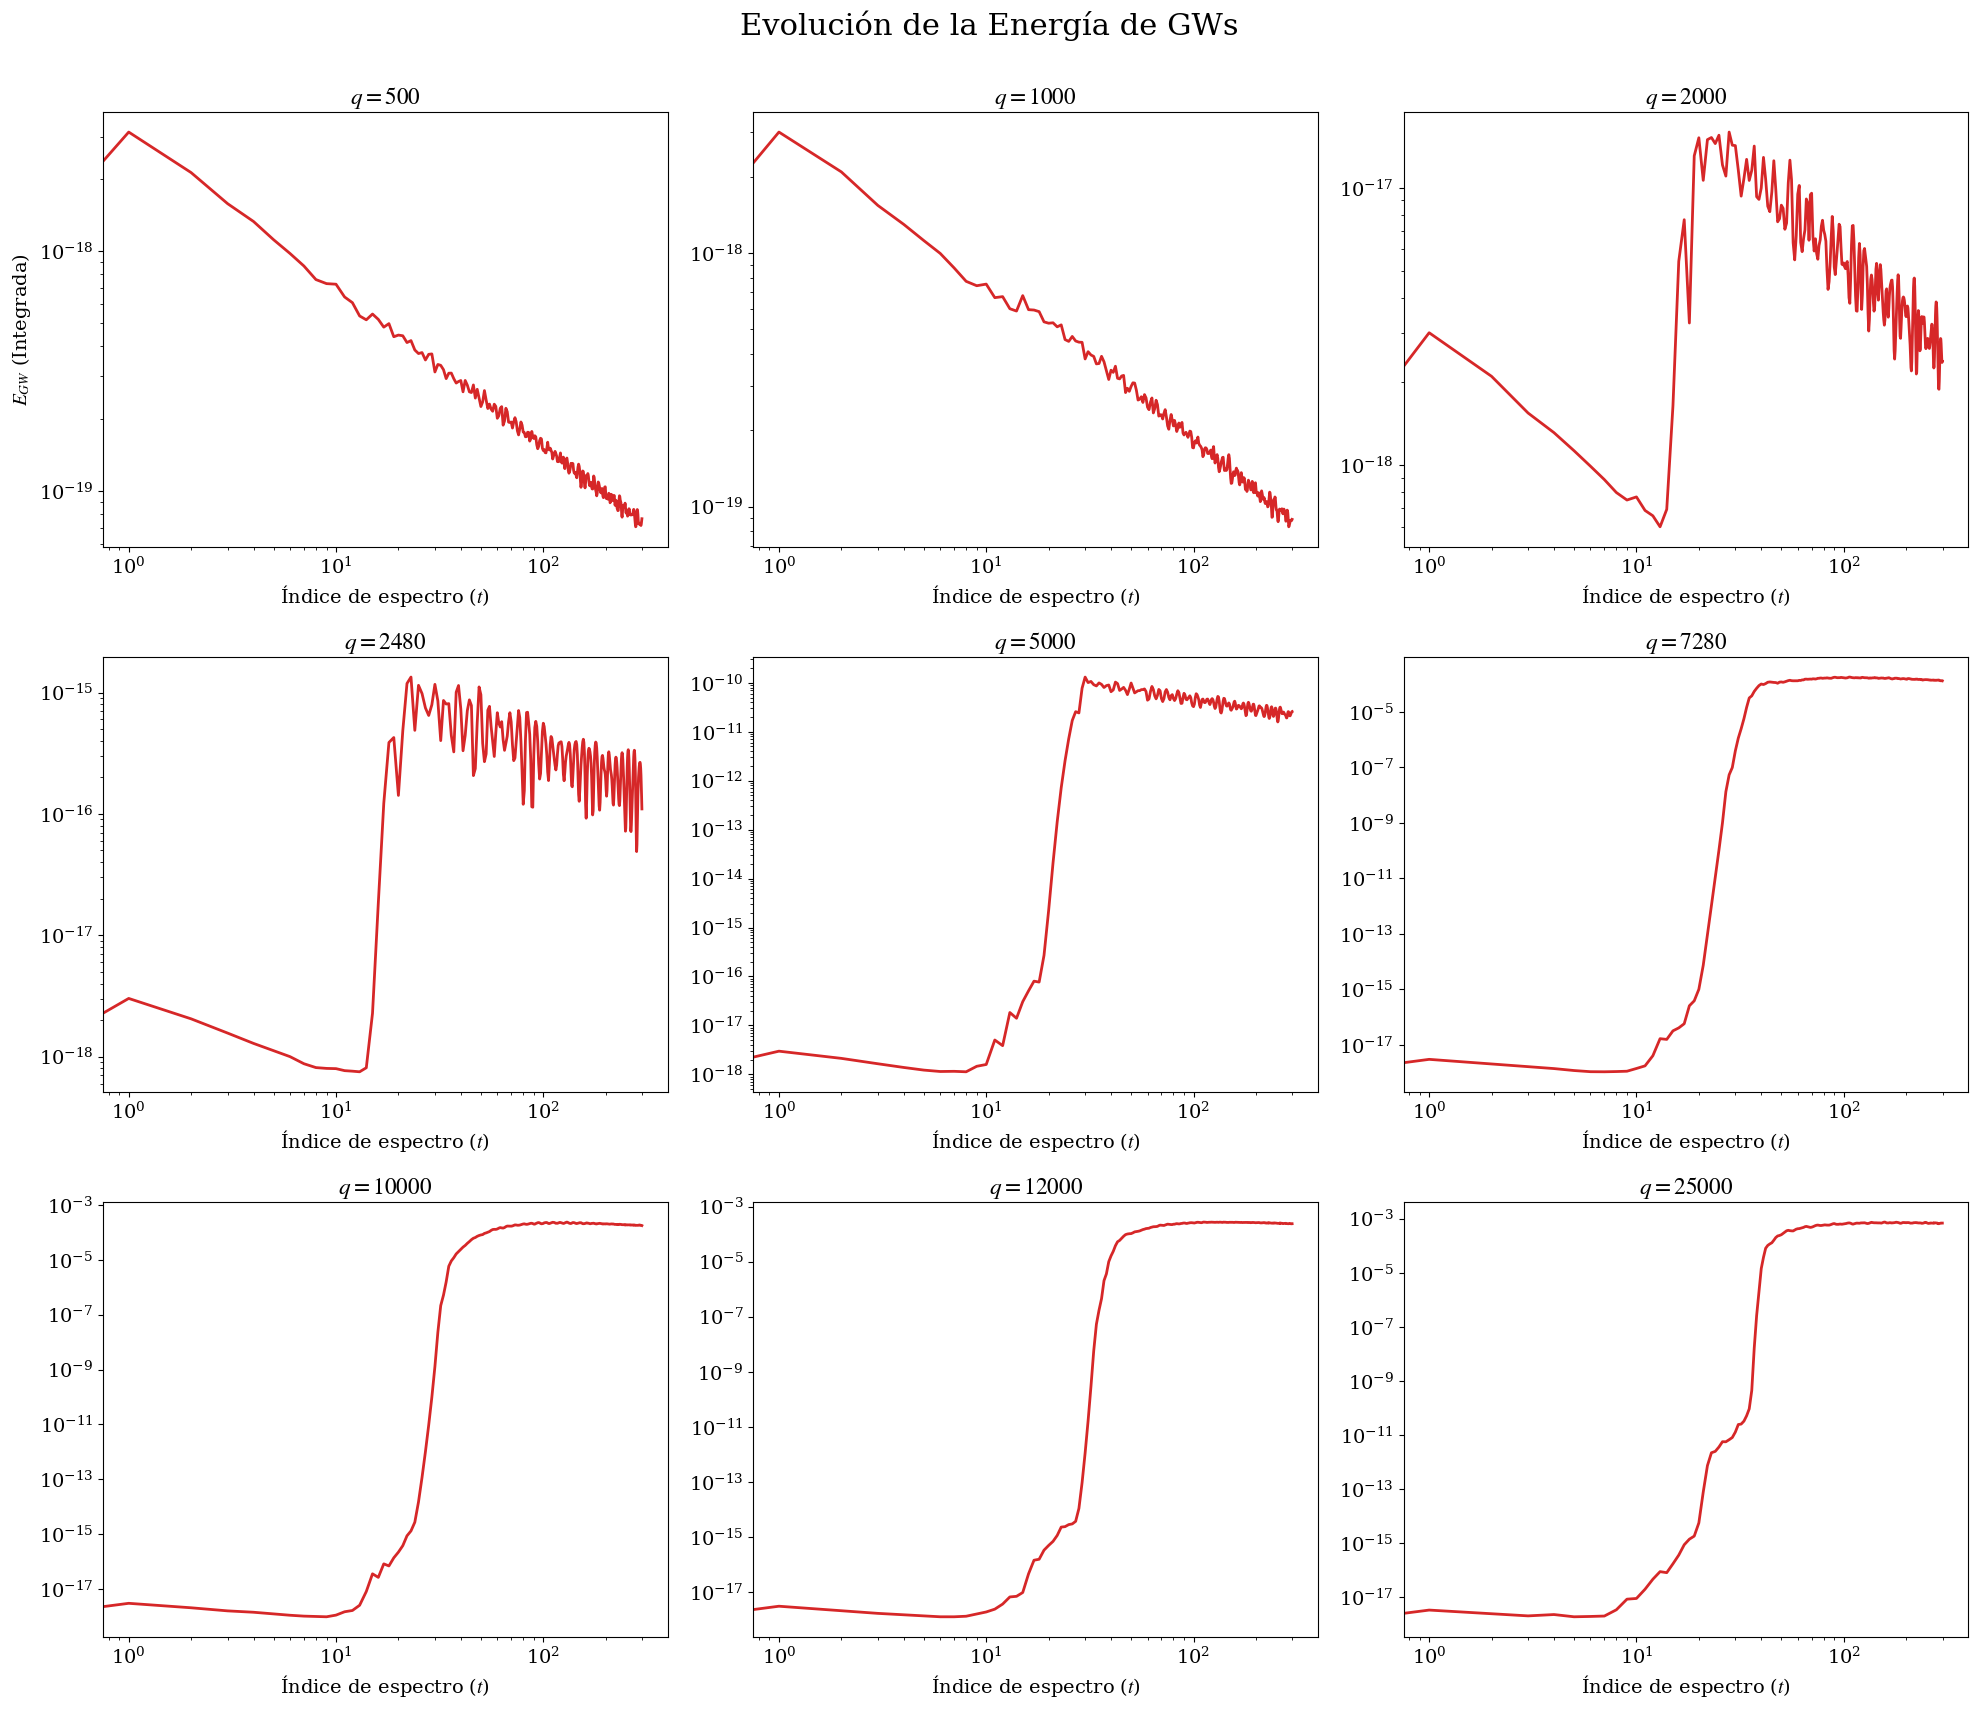

In [18]:
plot_combined_gw_energies([dir_m2phi2_q500, dir_m2phi2_q1000, dir_m2phi2_q2000, dir_m2phi2_q2480, dir_m2phi2_q5000, dir_m2phi2_q7280, dir_m2phi2_q10000, dir_m2phi2_q12000, dir_m2phi2_q25000], q_labels)

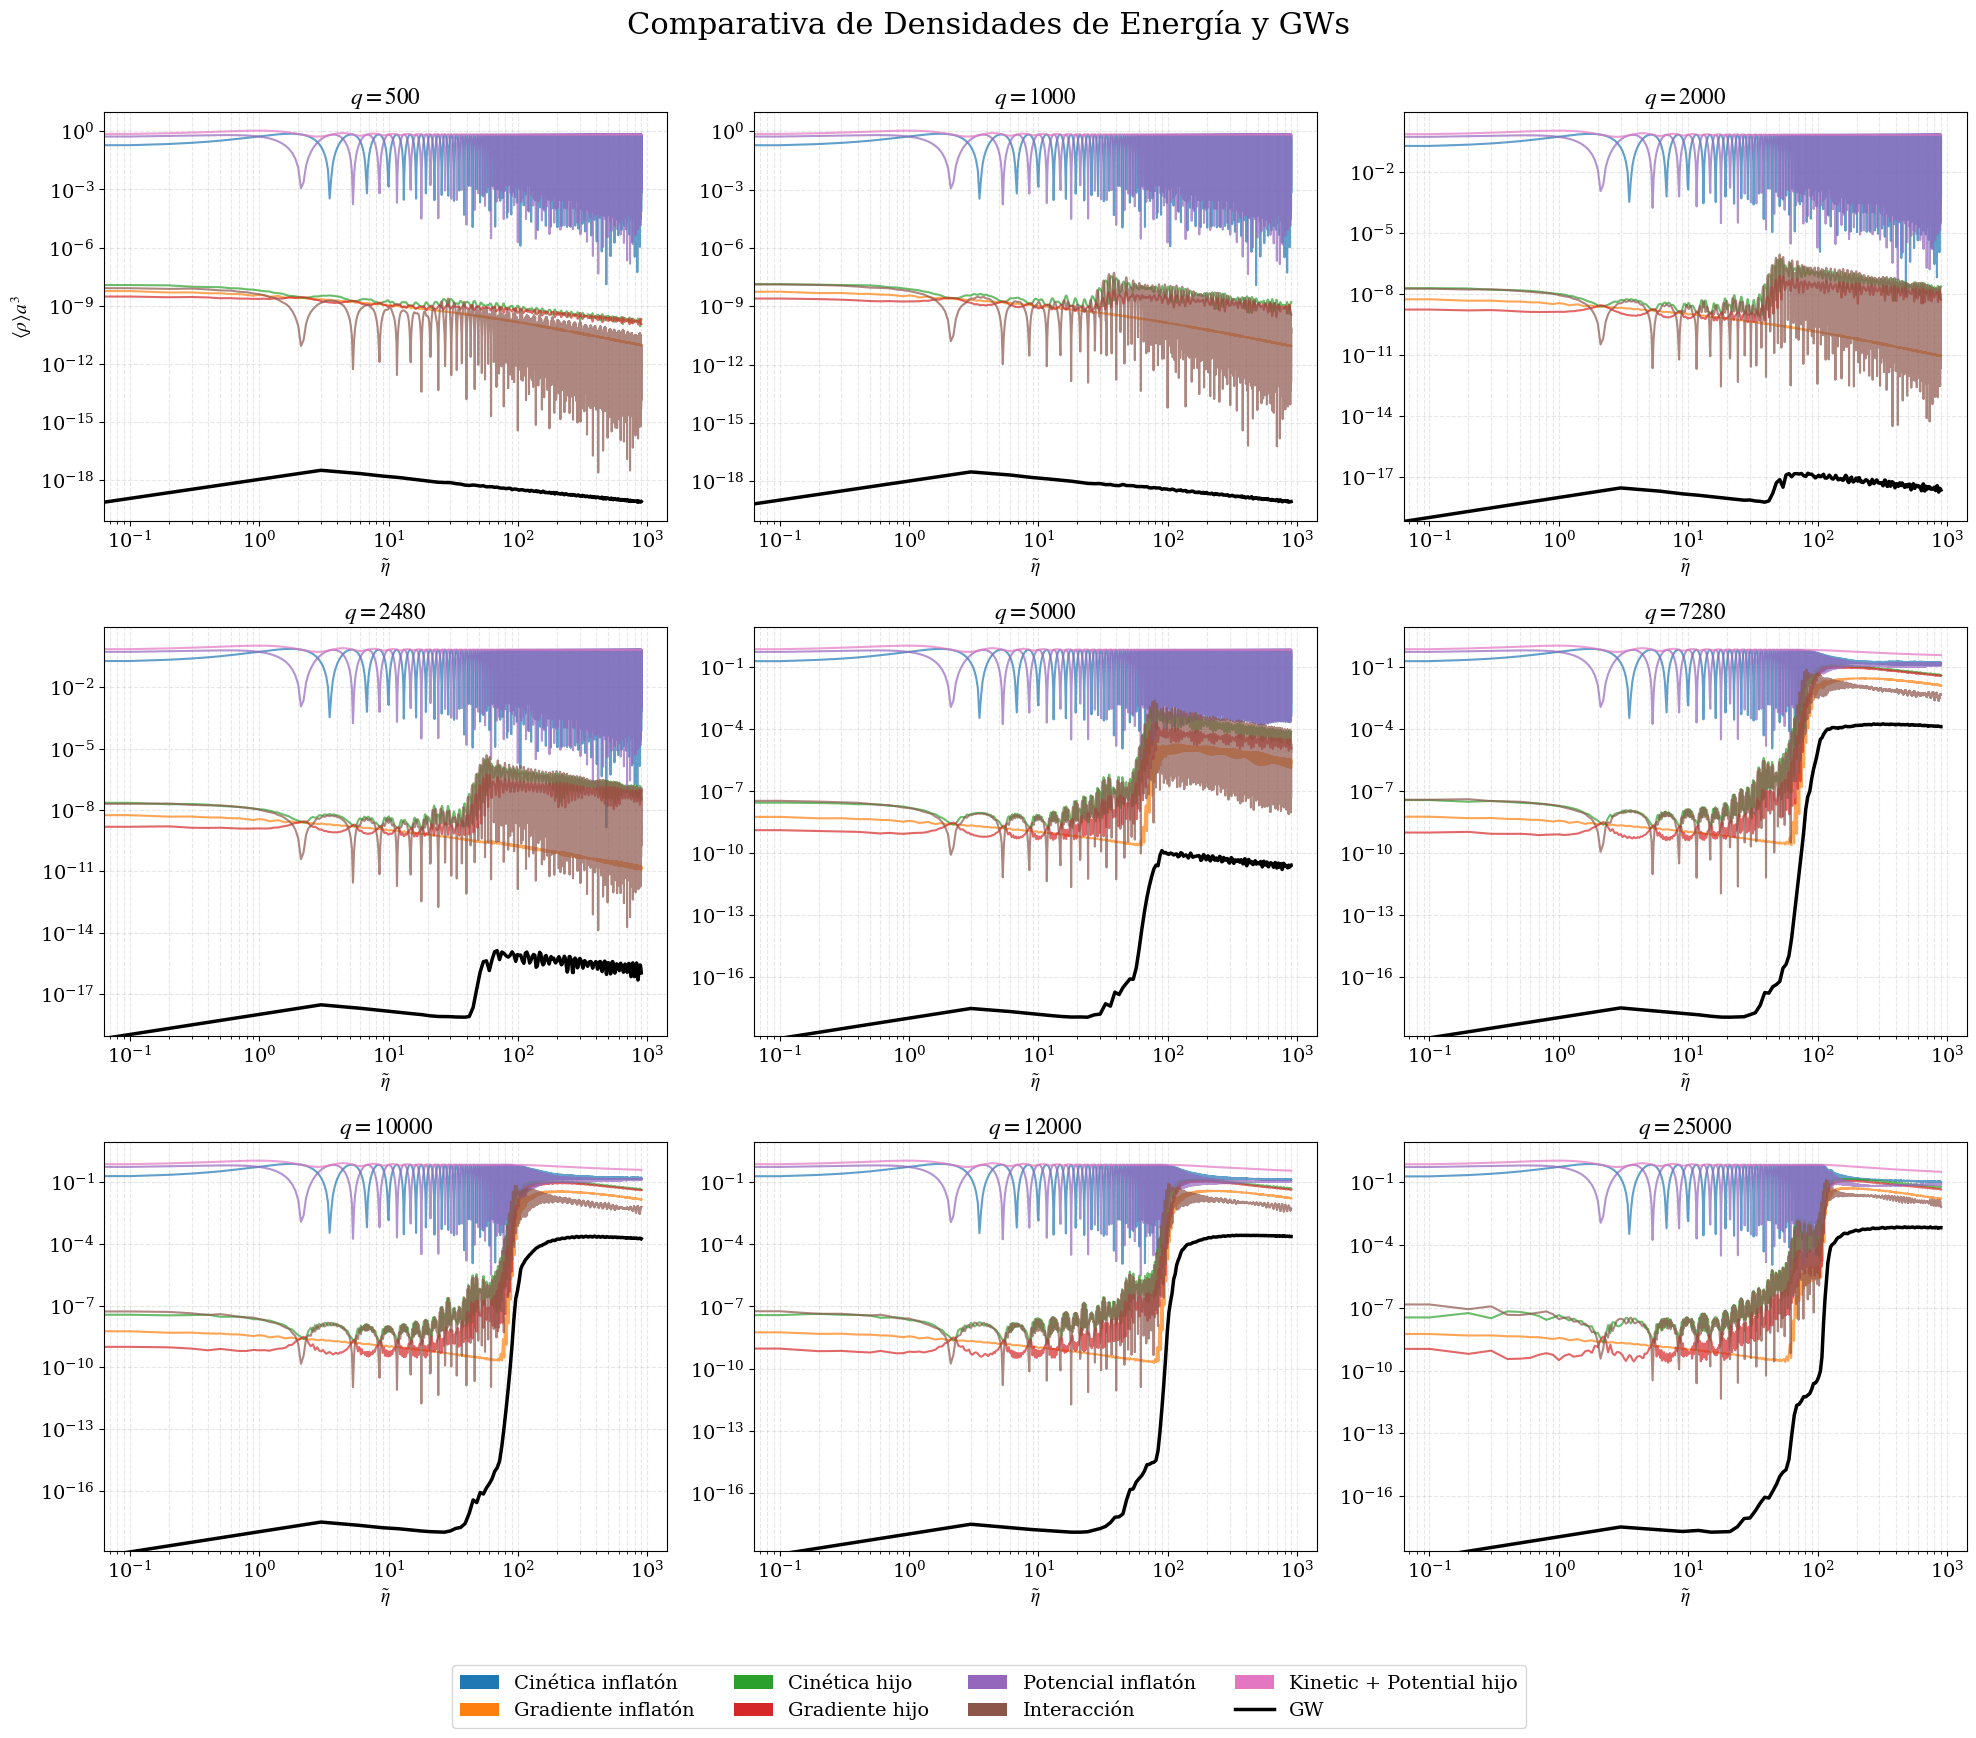

In [22]:
def plot_combined_total_energies(dir, aDat, m_val_labels):
    
    labels = ["Cinética inflatón", "Gradiente inflatón", "Cinética hijo", "Gradiente hijo", 
              "Potencial inflatón", "Interacción", "Kinetic + Potential hijo", "GW"]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "black"]
    
    fig = plt.figure(figsize=(20, 18))
    
    def plot_densities_and_gw(ax, dir_path, aDat, title):
        # 1. Cargar y graficar densidades de los campos
        en_path = os.path.join(dir_path, "average_energies.txt")
        if os.path.exists(en_path):
            enDat = np.loadtxt(en_path)
            nCols = enDat.shape[1]
            for col in range(1, nCols):
                ax.plot(enDat[:,0], enDat[:,col] * aDat[:,1]**3, color=colors[col-1], alpha=0.7)
        
        # 2. Cargar, integrar y graficar GWs
        gw_path = os.path.join(dir_path, "spectra_gws.txt")
        if os.path.exists(gw_path):
            # Usamos las funciones de carga y integración definidas previamente
            sp, nBins, nSpec = load_gws(gw_path)
            e_gw = integrate_gw_spectrum(sp, nBins, nSpec)
            # El factor '3' suele ser el intervalo de tiempo entre salidas de espectros
            ax.plot(np.arange(nSpec)*3, e_gw, color='black', lw=2.5, label='GW')
        
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_title(title)
        ax.set_xlabel(r"$\tilde{\eta}$")
        ax.grid(True, which='both', ls='--', alpha=0.3)

    for i in range(9):
        row, col = divmod(i, 3)
        ax = plt.subplot2grid((3, 3), (row, col))
        plot_densities_and_gw(ax, dir[i], aDat[i], fr"{m_val_labels[i]}")
        if i == 0: ax.set_ylabel(r"$\langle \rho \rangle a^3$")

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    # Leyenda única con el agregado de GW
    legend_elements = [Patch(facecolor=colors[i], label=labels[i]) for i in range(len(labels)-1)]
    legend_elements.append(plt.Line2D([0], [0], color='black', lw=2.5, label='GW'))
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=4, fontsize=14)
    plt.suptitle(fr"Comparativa de Densidades de Energía y GWs", fontsize=22)
    plt.show()

plot_combined_total_energies([dir_m2phi2_q500, dir_m2phi2_q1000, dir_m2phi2_q2000, dir_m2phi2_q2480, dir_m2phi2_q5000, dir_m2phi2_q7280, dir_m2phi2_q10000, dir_m2phi2_q12000, dir_m2phi2_q25000], [aDat_m2phi2_q500, aDat_m2phi2_q1000, aDat_m2phi2_q2000, aDat_m2phi2_q2480, aDat_m2phi2_q5000, aDat_m2phi2_q7280, aDat_m2phi2_q10000, aDat_m2phi2_q12000, aDat_m2phi2_q25000], q_labels)